# **Bowtie2 vs. Minimap2 vs. GMAP: A Performance and Efficiency Analysis**

## **A. Alignment Process** (bash pipeline)

First, we download the aligners Bowtie2, Minimap2 and GMAP and the necessary tools SAMtools, FastQC and wgsim which are going to be used for this analysis.

* *Important note: the following script which includes the genome download and sample preparation, the Bowtie2 indexing, alignment, the Minimap2 indexing, alignment, the GMAP indexing, alignment and SAMtools analysis is written in BASH script format. It can be ran through Jupyter Notebooks (due to %%bash). It's important to note that such computationally intensive tasks may be better suited for a dedicated terminal or a high-performance computing environment due to the potentially high demand on system resources.*

In [3]:
%%bash

# Update the package list
echo "Updating package list..."
apt-get update -y

# Install Bowtie2
echo "Installing Bowtie2..."
apt-get install -y bowtie2

# Verify installations
echo "Bowtie2 version:"
bowtie2 --version

# Install GMAP
echo "Installing GMAP..."
apt-get install -y gmap

echo "GMAP version:"
gmap --version

# Install FastQC
echo "Installing FastQC..."
apt-get install -y fastqc

echo "FastQC version:"
fastqc --version

# Install SAMtools
echo "Installing SAMtools..."
apt-get install -y samtools

echo "SAMtools version:"
samtools --version

echo "wgsim help:"
wgsim -help


wget https://github.com/lh3/minimap2/releases/download/v2.28/minimap2-2.28_x64-linux.tar.bz2
tar -xjf minimap2-2.28_x64-linux.tar.bz2
cd minimap2-2.28_x64-linux
chmod +x minimap2
sudo mv minimap2 /usr/local/bin/
cd ..
#Verify the installation
echo "Minimap2 version:"
minimap2 --version


Updating package list...
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Ign:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy Release [5,713 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy Release.gpg [793 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,196 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 https://r2u.stat.illinois.edu/ubuntu jam

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
GMAP version 2021-12-17 called with args: gmap.avx2 --version

Program: wgsim (short read simulator)
Version: 1.13
Contact: Heng Li <lh3@sanger.ac.uk>

Usage:   wgsim [options] <in.ref.fa> <out.read1.fq> <out.read2.fq>

Options: -e FLOAT      base error rate [0.000]
         -d INT        outer distance between the two ends [500]
         -s INT        standard deviation [50]
         -N INT        number of read pairs [1000000]
         -1 INT        length of the first read [70]
         -2 INT        length of the second read [70]
         -r FLOAT      rate of mutations [0.0010]
         -R FLOAT      fraction of indels [0.15]
         -X FLOAT      probability an indel is extended [0.30]
         -S INT        seed for random generator [0, use the current time]
         -A FLOAT      discard if 

### 1. Genome download and sample preparation

We first download and unzip the human genome (GRCh38.p13), a highly accurate
and comprehensive reference genome, retrieved from the NCBI FTP server.

Following the download, we create artificial paired-end sequencing samples using the wgsim tool, which simulates reads with specified read lengths (500 and 300 bases for two separate sets) and mutation rates. These mutation rates are set to 0.001 for both substitutions and indels (-r 0.001 -R 0.001), aligning with the natural mutation rates observed in human populations. We also generated 10.000 read pairs (N 10000) and a 0.01% error rate (-e 0.01). We then use FastQC to assess the quality of these synthetic reads, storing the results in the fastqc_results directory.

The set -e command ensures the script exits if any step fails, providing robustness to the workflow.

In [ ]:
%%bash

#!/bin/bash

# Exit immediately if a command exits with a non-zero status
set -e

# Download and unzip the human genome (GRCh38.p13)
echo "Downloading human genome..."
wget ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.28_GRCh38.p13/GCA_000001405.28_GRCh38.p13_genomic.fna.gz
gunzip GCA_000001405.28_GRCh38.p13_genomic.fna.gz

# Create artificial samples
echo "Creating artificial samples..."
wgsim -1 500 -2 500 -N 10000 -r 0.001 -R 0.001 -e 0.01 GCA_000001405.28_GRCh38.p13_genomic.fna output_reads_1.fq output_reads_2.fq
wgsim -1 300 -2 300 -N 10000 -r 0.001 -R 0.001 -e 0.01 GCA_000001405.28_GRCh38.p13_genomic.fna output_reads_3.fq output_reads_4.fq

# Run FastQC
echo "Running FastQC..."
mkdir -p fastqc_results
fastqc output_reads_1.fq output_reads_2.fq -o fastqc_results
fastqc output_reads_3.fq output_reads_4.fq -o fastqc_results

echo "Data preparation and FastQC complete."

### 2. Bowtie2 indexing, alignment (300bp, 500bp local and global) and SAMtools analysis

This script automates the process of aligning sequencing reads to a reference genome using Bowtie2 and processing the resulting alignments with SAMtools. Here's a detailed breakdown of the commands and flags used:

1. set -e: Ensures the script exits immediately if any command fails, preventing downstream errors.

2. THREADS=8: Defines the number of threads to use for parallel processing, set to 8 for this script.

3. Logging Setup: Redirects both standard output and error streams to a log file (bowtie2_script.log) using tee, allowing for real-time monitoring and log file creation.


---


4. Bowtie2 Index Building:

/usr/bin/time -v bowtie2-build --threads $THREADS GCA_000001405.28_GRCh38.p13_genomic.fna reference_index: Builds the Bowtie2 index from the human genome FASTA file, using 8 threads to speed up the process.

/usr/bin/time -v: it provides detailed statistics about the execution of the command that it is used infront of.

5. Read Alignment:

The script aligns paired-end reads (both 500 bp and 300 bp) to the reference genome using Bowtie2 with 8 threads (-p $THREADS).

Two types of alignments are performed for each read set: standard (-x reference_index) and local (--local -x reference_index), producing SAM files for each.

*Global alignment: Aligns sequences from end to end and ensures the entire length of both sequences is considered in the alignment.*

*Local alignment: Identifies and aligns the most similar regions within sequences and focuses on the best matching subsequences, not necessarily covering the entire length of the sequences.*

6. SAMtools Processing:

A loop processes each SAM file generated in the alignment step:
samtools view: Converts the SAM file to a BAM file.
samtools sort: Sorts the BAM file.
samtools index: Indexes the sorted BAM file for faster access.
samtools stats: Generates alignment statistics for the sorted BAM file.

In [ ]:
%%bash

#!/bin/bash

# Exit immediately if a command exits with a non-zero status
set -e

# Number of threads to use
THREADS=8

# Log file
LOGFILE="bowtie2_script.log"
exec > >(tee -i $LOGFILE)
exec 2>&1

# Build Bowtie2 index
echo "Building Bowtie2 index..."
/usr/bin/time -v bowtie2-build --threads $THREADS GCA_000001405.28_GRCh38.p13_genomic.fna reference_index

# Align reads using Bowtie2
echo "Aligning reads with Bowtie2..."

# Paired-end reads (500 bp)
echo "Aligning 500 bp reads..."
/usr/bin/time -v bowtie2 -p $THREADS -x reference_index -1 output_reads_1.fq -2 output_reads_2.fq -S output_bowtie2_500bp.sam || { echo "500 bp alignment failed"; exit 1; }
/usr/bin/time -v bowtie2 -p $THREADS --local -x reference_index -1 output_reads_1.fq -2 output_reads_2.fq -S output_local_bowtie2_500bp.sam || { echo "500 bp local alignment failed"; exit 1; }

# Paired-end reads (300 bp)
echo "Aligning 300 bp reads..."
/usr/bin/time -v bowtie2 -p $THREADS -x reference_index -1 output_reads_3.fq -2 output_reads_4.fq -S output_bowtie2_300bp.sam || { echo "300 bp alignment failed"; exit 1; }
/usr/bin/time -v bowtie2 -p $THREADS --local -x reference_index -1 output_reads_3.fq -2 output_reads_4.fq -S output_local_bowtie2_300bp.sam || { echo "300 bp local alignment failed"; exit 1; }

# Process SAM files with SAMtools
echo "Processing SAM files with SAMtools..."

# List of SAM files to process
sam_files=("output_bowtie2_500bp.sam" "output_local_bowtie2_500bp.sam" "output_bowtie2_300bp.sam" "output_local_bowtie2_300bp.sam")

for sam_file in "${sam_files[@]}"
do
  echo "Processing $sam_file..."
  bam_file="${sam_file%.sam}.bam"
  sorted_bam_file="${bam_file%.bam}_sorted.bam"
  stats_file="${sorted_bam_file%.bam}_stats.txt"

  samtools view -bS $sam_file > $bam_file || { echo "samtools view failed for $sam_file"; exit 1; }
  samtools sort $bam_file -o $sorted_bam_file || { echo "samtools sort failed for $bam_file"; exit 1; }
  samtools index $sorted_bam_file || { echo "samtools index failed for $sorted_bam_file"; exit 1; }
  samtools stats $sorted_bam_file > $stats_file || { echo "samtools stats failed for $sorted_bam_file"; exit 1; }
done

echo "Bowtie2 alignment and SAMtools processing complete."

### 3. Minimap2 indexing, alignment (300bp and 500bp), SAMtools analysis

1. Similarly to Bowtie2_script, the script sets the number of threads to 8 and configures logging to capture both standard output and errors.

2. It indexes the reference genome using Minimap2 with the -d flag to create an index file (reference_index_minimap2.mmi) and the -t flag to specify 8 threads.

3. Alignments:
Aligns 500 bp paired-end reads in sensitive mode (-ax sr).

Aligns 300 bp paired-end reads in sensitive mode.

Aligns 500 bp paired-end reads in assembly mode (-ax asm5).

Each alignment runs in the background concurrently.

*-ax sr is used for short read alignments, providing high sensitivity and accuracy for typical high-throughput sequencing data.*

*-ax asm5 is used for aligning longer, assembled sequences with up to 5% divergence, accommodating more significant variations and structural differences.*

4. SAMtools Processing:

Converts SAM files to BAM format (samtools view).

Sorts BAM files (samtools sort).

Indexes sorted BAM files (samtools index).

Generates alignment statistics (samtools stats).

In [ ]:
#!/bin/bash

# Exit immediately if a command exits with a non-zero status
set -e

# Number of threads to use
THREADS=8

# Log file
LOGFILE="minimap2_script.log"
exec > >(tee -i $LOGFILE)
exec 2>&1

# Indexing the reference genome with minimap2
echo "Indexing the reference genome with minimap2..."
/usr/bin/time -v minimap2 -t $THREADS -d reference_index_minimap2.mmi GCA_000001405.28_GRCh38.p13_genomic.fna

# Aligning paired-end reads (500 bp each) to the indexed reference using minimap2 in sensitive mode (-ax sr)
echo "Aligning paired-end reads (500 bp each) to the indexed reference using minimap2..."
/usr/bin/time -v minimap2 -ax sr -t $THREADS reference_index_minimap2.mmi output_reads_1.fq output_reads_2.fq > output_minimap2_500bp.sam &

# Aligning paired-end reads (300 bp each) to the indexed reference using minimap2 in sensitive mode (-ax sr)
echo "Aligning paired-end reads (300 bp each) to the indexed reference using minimap2..."
/usr/bin/time -v minimap2 -ax sr -t $THREADS reference_index_minimap2.mmi output_reads_3.fq output_reads_4.fq > output_minimap2_300bp.sam &

# Aligning paired-end reads (500 bp each) to the indexed reference using minimap2 in assembly mode (-ax asm5), used here as 500 bp reads are on the longer end
echo "Aligning paired-end reads (500 bp each) to the indexed reference using minimap2 in assembly mode..."
/usr/bin/time -v minimap2 -ax asm5 -t $THREADS reference_index_minimap2.mmi output_reads_1.fq output_reads_2.fq > output_minimap2_asm5_500bp.sam &

# Wait for all background processes to complete
wait

# Process SAM files with SAMtools
echo "Processing SAM files with SAMtools..."

# List of SAM files to process
sam_files=("output_minimap2_500bp.sam" "output_minimap2_300bp.sam" "output_minimap2_asm5_500bp.sam")

 for sam_file in "${sam_files[@]}"
 do
   echo "Processing $sam_file..."
   bam_file="${sam_file%.sam}.bam"
   sorted_bam_file="${bam_file%.bam}_sorted.bam"
   stats_file="${sorted_bam_file%.bam}_stats.txt"

  samtools view -bS $sam_file > $bam_file || { echo "samtools view failed for $sam_file"; exit 1; }
  samtools sort $bam_file -o $sorted_bam_file || { echo "samtools sort failed for $bam_file"; exit 1; }
  samtools index $sorted_bam_file || { echo "samtools index failed for $sorted_bam_file"; exit 1; }
  samtools stats $sorted_bam_file > $stats_file || { echo "samtools stats failed for $sorted_bam_file"; exit 1; }
done

echo "Minimap2 alignment and SAMtools processing complete."

### 3. GMAP indexing, alignment (300bp and 500bp) and SAMtools analysis

1. Defines 8 threads for parallel processing and configuring logging to capture both standard output and errors.

2. Index Directory: It creates an index directory (genome_index_gmap) if it does not already exist.

3. Indexes the reference genome using GMAP. Indexing is done serially as GMAP doesn't allow for use of multiple cores for indexing.

4. Alignments:

500 bp Reads: Aligns paired-end reads of 500 bp using GMAP with the -f sampe flag for paired-end reads and -t $THREADS to use 8 threads. The result is saved as output_gmap_500bp.sam.

Similarly aligns 300 bp paired-end reads and outputs the result to output_gmap_300bp.sam.

Both alignments are executed in parallel.

5. SAMtools Processing:

Converts SAM files to BAM format (samtools view).

Sorts the BAM files (samtools sort).

Indexes the sorted BAM files (samtools index).

Generates alignment statistics for the BAM files (samtools stats).

In [ ]:
#!/bin/bash

# Exit immediately if a command exits with a non-zero status
set -e

# Number of threads to use
THREADS=8

# Log file
LOGFILE="gmap_script.log"
exec > >(tee -i $LOGFILE)
exec 2>&1

# Create index directory if it doesn't exist
INDEX_DIR="genome_index_gmap"
mkdir -p $INDEX_DIR

# Indexing the reference genome with GMAP (indexing is not parallelizable)
echo "Indexing the reference genome with GMAP..."
/usr/bin/time -v gmap_build -d GRCh38 -D $INDEX_DIR GCA_000001405.28_GRCh38.p13_genomic.fna

# Aligning paired-end reads (500 bp each) to the indexed reference using GMAP
echo "Aligning paired-end reads (500 bp each) to the indexed reference using GMAP..."
/usr/bin/time -v gmap -d GRCh38 -D $INDEX_DIR -f sampe -t $THREADS output_reads_1.fq output_reads_2.fq > output_gmap_500bp.sam &

# Aligning paired-end reads (300 bp each) to the indexed reference using GMAP
echo "Aligning paired-end reads (300 bp each) to the indexed reference using GMAP..."
/usr/bin/time -v gmap -d GRCh38 -D $INDEX_DIR -f sampe -t $THREADS output_reads_3.fq output_reads_4.fq > output_gmap_300bp.sam &

# Wait for all background processes to complete
wait

# Process SAM files with SAMtools
echo "Processing SAM files with SAMtools..."

# List of SAM files to process
sam_files=("output_gmap_500bp.sam" "output_gmap_300bp.sam")

 for sam_file in "${sam_files[@]}"
 do
   echo "Processing $sam_file..."
   bam_file="${sam_file%.sam}.bam"
   sorted_bam_file="${bam_file%.bam}_sorted.bam"
   stats_file="${sorted_bam_file%.bam}_stats.txt"

  samtools view -bS $sam_file > $bam_file || { echo "samtools view failed for $sam_file"; exit 1; }
  samtools sort $bam_file -o $sorted_bam_file || { echo "samtools sort failed for $bam_file"; exit 1; }
  samtools index $sorted_bam_file || { echo "samtools index failed for $sorted_bam_file"; exit 1; }
  samtools stats $sorted_bam_file > $stats_file || { echo "samtools stats failed for $sorted_bam_file"; exit 1; }
done

echo "GMAP alignment and SAMtools processing complete."

## **B. Statistical Analysis of Different Metrics & Alignment Statistics** (python pipeline)

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Function Descriptions

### `parse_bowtie2_log(log_file)`
Parses a Bowtie2 log file to extract performance metrics into a pandas DataFrame. The extracted metrics include user time, system time, elapsed time, CPU usage, and maximum resident set size for each step of the Bowtie2 process.

### `parse_minimap2_log(log_file)`
Parses a Minimap2 log file to extract performance metrics into a pandas DataFrame. This function is similar to `parse_bowtie2_log` and `parse_gmap_log`, focusing on metrics such as user time, system time, elapsed time, CPU usage, and maximum resident set size for Minimap2 steps.

### `parse_gmap_log(log_file)`
Parses a GMAP log file to extract performance metrics into a pandas DataFrame. It extracts similar metrics as the Bowtie2 and Minimap2 log parsers, including user time, system time, elapsed time, CPU usage, and maximum resident set size.

### `plot_log_metric(df, metric, title)`
Plots a specified log file metric from a DataFrame using Seaborn. It generates a bar plot for the given metric and includes annotations on the bars with the metric values.

### `plot_all_log_metrics(df)`
Automates the plotting of key performance log file metrics for each step from a DataFrame. It uses the `plot_log_metric` function to create bar plots for user time, system time, elapsed time, CPU usage, and maximum resident set size.

### `parse_stats(file_path)`
Parses a samtools stats file and extracts key metrics into a dictionary. Metrics include raw total sequences, reads mapped, reads unmapped, reads properly paired, mismatches, error rate, and average quality.

### `create_data_dict_300(local_bowtie2_file, bowtie2_file, minimap2_file, gmap_file)`
Creates a data dictionary for 300 bp reads from samtools stats files for various aligners. The dictionary contains metrics for each aligner, including raw total sequences, reads mapped, reads unmapped, and other key performance indicators.

### `create_data_dict_500(local_bowtie2_file, bowtie2_file, minimap2_sr_file, minimap2_asm5_file, gmap_file)`
Creates a data dictionary for 500 bp reads from samtools stats files, including additional Minimap2 modes (sensitive and assembly). The dictionary includes metrics similar to those in `create_data_dict_300`, but with additional aligner modes.

### `create_dataframe_300(data)`
Creates and preprocesses a DataFrame from a 300 bp reads data dictionary. The DataFrame includes calculated alignment rates and accuracies for various aligners and is prepared for plotting.

### `create_dataframe_500(data)`
Creates and preprocesses a DataFrame from a 500 bp reads data dictionary. Similar to `create_dataframe_300`, but includes additional Minimap2 modes and prepares the DataFrame for plotting.

### `plot_stats_metric(df, metric)`
Plots a specific samtools stats metric from a DataFrame using Seaborn. It generates a bar plot for the specified metric and includes value annotations on the bars.

### `plot_all_stats_metrics(df)`
Plots all specified samtools stats metrics from a DataFrame. It uses the `plot_stats_metric` function to create bar plots for metrics such as raw total sequences, reads mapped, reads unmapped, reads properly paired, mismatches, error rate, average quality, alignment rate, and accuracy.


In [ ]:
def parse_bowtie2_log(log_file):
    """
    Parses the log file from Bowtie2 and extracts performance metrics into a DataFrame.

    Args:
        log_file (str): Path to the Bowtie2 log file.

    Returns:
        pd.DataFrame: A DataFrame containing extracted metrics.
    """
    with open(log_file, 'r') as file:
        content = file.read()

    # Split the log content into sections based on 'Command being timed:'
    sections = re.split(r'Command being timed:', content)

    # Initialize a dictionary to store the extracted metrics
    metrics = {
        'Step': [],
        'User Time (s)': [],
        'System Time (s)': [],
        'Elapsed Time (s)': [],
        'CPU Usage (%)': [],
        'Maximum Resident Set Size (kB)': [],
    }

    # Process each section, skipping the first split which is not a timed command
    for section in sections[1:]:
        step = re.search(r'"\s*([^\n]+)"', section).group(1)

        # Extract and convert metrics from each section
        user_time = float(re.search(r'User time \(seconds\):\s*([0-9.]+)', section).group(1))
        system_time = float(re.search(r'System time \(seconds\):\s*([0-9.]+)', section).group(1))
        elapsed_time = re.search(r'Elapsed \(wall clock\) time \(h:mm:ss or m:ss\):\s*([0-9:]+)', section).group(1)
        cpu_usage = float(re.search(r'Percent of CPU this job got:\s*([0-9.]+)', section).group(1))
        max_res_size = int(re.search(r'Maximum resident set size \(kbytes\):\s*([0-9.]+)', section).group(1))

        # Convert elapsed time to seconds
        elapsed_parts = list(map(float, elapsed_time.split(':')))
        elapsed_seconds = elapsed_parts[-1] + 60 * elapsed_parts[-2] + (3600 * elapsed_parts[-3] if len(elapsed_parts) == 3 else 0)

        # Append the extracted metrics to lists
        metrics['Step'].append(step)
        metrics['User Time (s)'].append(user_time)
        metrics['System Time (s)'].append(system_time)
        metrics['Elapsed Time (s)'].append(elapsed_seconds)
        metrics['CPU Usage (%)'].append(cpu_usage)
        metrics['Maximum Resident Set Size (kB)'].append(max_res_size)

    # Return the metrics as a DataFrame
    return pd.DataFrame(metrics)

def parse_minimap2_log(log_file):
    """
    Parses the log file from Minimap2 and extracts performance metrics into a DataFrame.

    Args:
        log_file (str): Path to the Minimap2 log file.

    Returns:
        pd.DataFrame: A DataFrame containing extracted metrics.
    """
    with open(log_file, 'r') as file:
        content = file.read()

    # Initialize a dictionary to store the extracted metrics
    metrics = {
        'Step': [],
        'User Time (s)': [],
        'System Time (s)': [],
        'Elapsed Time (s)': [],
        'CPU Usage (%)': [],
        'Maximum Resident Set Size (kB)': [],
    }

    # Split the log content into sections based on 'Command being timed:'
    sections = re.split(r'Command being timed:', content)

    # Process each section, skipping the first split which is not a timed command
    for section in sections[1:]:
        step = re.search(r'"\s*([^\n]+)"', section).group(1).strip()

        user_time = float(re.search(r'User time \(seconds\):\s*([0-9.]+)', section).group(1))
        system_time = float(re.search(r'System time \(seconds\):\s*([0-9.]+)', section).group(1))
        elapsed_time = re.search(r'Elapsed \(wall clock\) time \(h:mm:ss or m:ss\):\s*([0-9:]+)', section).group(1)
        cpu_usage = float(re.search(r'Percent of CPU this job got:\s*([0-9.]+)', section).group(1))
        max_res_size = int(re.search(r'Maximum resident set size \(kbytes\):\s*([0-9.]+)', section).group(1))

        elapsed_parts = list(map(float, elapsed_time.split(':')))
        elapsed_seconds = elapsed_parts[-1] + 60 * elapsed_parts[-2] + (3600 * elapsed_parts[-3] if len(elapsed_parts) == 3 else 0)

        metrics['Step'].append(step)
        metrics['User Time (s)'].append(user_time)
        metrics['System Time (s)'].append(system_time)
        metrics['Elapsed Time (s)'].append(elapsed_seconds)
        metrics['CPU Usage (%)'].append(cpu_usage)
        metrics['Maximum Resident Set Size (kB)'].append(max_res_size)

    # Return the metrics as a DataFrame
    return pd.DataFrame(metrics)

def parse_gmap_log(log_file):
    """
    Parses the log file from GMAP and extracts performance metrics into a DataFrame.

    Args:
        log_file (str): Path to the GMAP log file.

    Returns:
        pd.DataFrame: A DataFrame containing extracted metrics.
    """
    with open(log_file, 'r') as file:
        content = file.read()

    # Initialize a dictionary to store the extracted metrics
    metrics = {
        'Step': [],
        'User Time (s)': [],
        'System Time (s)': [],
        'Elapsed Time (s)': [],
        'CPU Usage (%)': [],
        'Maximum Resident Set Size (kB)': [],
    }

    # Split the log content into sections based on 'Command being timed:'
    sections = re.split(r'Command being timed:', content)

    # Process each section, skipping the first split which is not a timed command
    for section in sections[1:]:
        step_match = re.search(r'"\s*([^\n]+)"', section)
        user_time_match = re.search(r'User time \(seconds\):\s*([0-9.]+)', section)
        system_time_match = re.search(r'System time \(seconds\):\s*([0-9.]+)', section)
        elapsed_time_match = re.search(r'Elapsed \(wall clock\) time \(h:mm:ss or m:ss\):\s*([0-9:]+)', section)
        cpu_usage_match = re.search(r'Percent of CPU this job got:\s*([0-9.]+)', section)
        max_res_size_match = re.search(r'Maximum resident set size \(kbytes\):\s*([0-9.]+)', section)

        if step_match and user_time_match and system_time_match and elapsed_time_match and cpu_usage_match and max_res_size_match:
            step = step_match.group(1).strip()
            user_time = float(user_time_match.group(1))
            system_time = float(system_time_match.group(1))
            elapsed_time = elapsed_time_match.group(1)
            cpu_usage = float(cpu_usage_match.group(1))
            max_res_size = int(max_res_size_match.group(1))

            elapsed_parts = list(map(float, elapsed_time.split(':')))
            elapsed_seconds = elapsed_parts[-1] + 60 * elapsed_parts[-2] + (3600 * elapsed_parts[-3] if len(elapsed_parts) == 3 else 0)

            metrics['Step'].append(step)
            metrics['User Time (s)'].append(user_time)
            metrics['System Time (s)'].append(system_time)
            metrics['Elapsed Time (s)'].append(elapsed_seconds)
            metrics['CPU Usage (%)'].append(cpu_usage)
            metrics['Maximum Resident Set Size (kB)'].append(max_res_size)

    # Return the metrics as a DataFrame
    return pd.DataFrame(metrics)

def plot_log_metric(df, metric, title):
    """
    Plots the specified log file metric from the DataFrame using Seaborn.

    Args:
        df (pd.DataFrame): DataFrame containing the metrics.
        metric (str): The metric to plot.
        title (str): Title of the plot.
    """
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x=df[metric], y=df['Step'], palette="viridis")
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel('Step', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    # Annotate the bars with the metric values
    for p in ax.patches:
        ax.annotate(format(p.get_width(), '.2f'),
                   (p.get_width(), p.get_y() + p.get_height() / 2.),
                   ha='center', va='center',
                   xytext=(5, 0),
                   textcoords='offset points')
    plt.tight_layout()
    plt.show()

def plot_all_log_metrics(df):
    """
    Automates plotting of key performance log file metrics for each step from a given DataFrame using Seaborn.

    Args:
        df (pd.DataFrame): DataFrame containing the metrics.
    """
    # List of metrics and their corresponding plot titles
    metrics = [
        ('User Time (s)', 'User Time for Each Step'),
        ('System Time (s)', 'System Time for Each Step'),
        ('Elapsed Time (s)', 'Elapsed Time for Each Step'),
        ('CPU Usage (%)', 'CPU Usage for Each Step'),
        ('Maximum Resident Set Size (kB)', 'Maximum Resident Set Size for Each Step')
    ]

    for metric, title in metrics:
        plot_log_metric(df, metric, title)

def parse_stats(file_path):
    """
    Parses a samtools stats file and extracts key metrics into a dictionary.

    Args:
        file_path (str): The path to the samtools stats file.

    Returns:
        dict: A dictionary containing the extracted metrics.
    """
    # Initialize an empty dictionary to hold the metrics
    metrics = {}

    # Open the file in read mode
    with open(file_path, 'r') as file:
        # Iterate through each line in the file
        for line in file:
            # Check if the line starts with 'SN' (summary numbers)
            if line.startswith('SN'):
                # Split the line by tab characters
                parts = line.strip().split('\t')
                # The key is the second element, removing any colons and extra spaces
                key = parts[1].replace(':', '').strip()
                # The value is the third element, stripping spaces and removing commas
                value = parts[2].strip().replace(',', '')
                try:
                    # Attempt to convert the value to a float and store it in the dictionary
                    metrics[key] = float(value)
                except ValueError:
                    # If conversion fails, store the value as a string
                    metrics[key] = value
    return metrics

def create_data_dict_300(local_bowtie2_file, bowtie2_file, minimap2_file, gmap_file):
    """
    Creates a data dictionary for 300 bp reads for plotting from samtools stats files.

    Args:
        local_bowtie2_file (str): The path to the local Bowtie2 stats file.
        bowtie2_file (str): The path to the Bowtie2 stats file.
        minimap2_file (str): The path to the Minimap2 stats file.
        gmap_file (str): The path to the GMAP stats file.

    Returns:
        dict: A dictionary containing the metrics for each aligner.
    """
    # Parse stats files for each aligner
    local_bowtie2_stats = parse_stats(local_bowtie2_file)
    bowtie2_stats = parse_stats(bowtie2_file)
    minimap2_stats = parse_stats(minimap2_file)
    gmap_stats = parse_stats(gmap_file)

    # Create a dictionary to hold data for each aligner
    data = {
        'Metric': [
            'raw total sequences', 'reads mapped', 'reads unmapped', 'reads properly paired',
            'mismatches', 'error rate', 'average quality'
        ],
        'Local Bowtie2': [
            local_bowtie2_stats.get('raw total sequences', 0),
            local_bowtie2_stats.get('reads mapped', 0),
            local_bowtie2_stats.get('reads unmapped', 0),
            local_bowtie2_stats.get('reads properly paired', 0),
            local_bowtie2_stats.get('mismatches', 0),
            local_bowtie2_stats.get('error rate', 0),
            local_bowtie2_stats.get('average quality', 0)
        ],
        'Bowtie2': [
            bowtie2_stats.get('raw total sequences', 0),
            bowtie2_stats.get('reads mapped', 0),
            bowtie2_stats.get('reads unmapped', 0),
            bowtie2_stats.get('reads properly paired', 0),
            bowtie2_stats.get('mismatches', 0),
            bowtie2_stats.get('error rate', 0),
            bowtie2_stats.get('average quality', 0)
        ],
        'Minimap2': [
            minimap2_stats.get('raw total sequences', 0),
            minimap2_stats.get('reads mapped', 0),
            minimap2_stats.get('reads unmapped', 0),
            minimap2_stats.get('reads properly paired', 0),
            minimap2_stats.get('mismatches', 0),
            minimap2_stats.get('error rate', 0),
            minimap2_stats.get('average quality', 0)
        ],
        'GMAP': [
            gmap_stats.get('raw total sequences', 0),
            gmap_stats.get('reads mapped', 0),
            gmap_stats.get('reads unmapped', 0),
            gmap_stats.get('reads properly paired', 0),
            gmap_stats.get('mismatches', 0),
            gmap_stats.get('error rate', 0),
            gmap_stats.get('average quality', 0)
        ]
    }

    return data

def create_data_dict_500(local_bowtie2_file, bowtie2_file, minimap2_sr_file, minimap2_asm5_file, gmap_file):
    """
    Creates a data dictionary for 500 bp reads for plotting from samtools stats files.

    Args:
        local_bowtie2_file (str): The path to the local Bowtie2 stats file.
        bowtie2_file (str): The path to the Bowtie2 stats file.
        minimap2_sr_file (str): The path to the sensitive mode Minimap2 stats file.
        minimap2_asm5_file (str): The path to the assembly mode Minimap2 stats file.
        gmap_file (str): The path to the GMAP stats file.

    Returns:
        dict: A dictionary containing the metrics for each aligner.
    """
    # Parse stats files for each aligner, including additional Minimap2 modes
    local_bowtie2_stats = parse_stats(local_bowtie2_file)
    bowtie2_stats = parse_stats(bowtie2_file)
    minimap2_sr_stats = parse_stats(minimap2_sr_file)
    minimap2_asm5_stats = parse_stats(minimap2_asm5_file)
    gmap_stats = parse_stats(gmap_file)

    # Create a dictionary to hold data for each aligner
    data = {
        'Metric': [
            'raw total sequences', 'reads mapped', 'reads unmapped', 'reads properly paired',
            'mismatches', 'error rate', 'average quality'
        ],
        'Local Bowtie2': [
            local_bowtie2_stats.get('raw total sequences', 0),
            local_bowtie2_stats.get('reads mapped', 0),
            local_bowtie2_stats.get('reads unmapped', 0),
            local_bowtie2_stats.get('reads properly paired', 0),
            local_bowtie2_stats.get('mismatches', 0),
            local_bowtie2_stats.get('error rate', 0),
            local_bowtie2_stats.get('average quality', 0)
        ],
        'Bowtie2': [
            bowtie2_stats.get('raw total sequences', 0),
            bowtie2_stats.get('reads mapped', 0),
            bowtie2_stats.get('reads unmapped', 0),
            bowtie2_stats.get('reads properly paired', 0),
            bowtie2_stats.get('mismatches', 0),
            bowtie2_stats.get('error rate', 0),
            bowtie2_stats.get('average quality', 0)
        ],
        'Sensitive Minimap2': [
            minimap2_sr_stats.get('raw total sequences', 0),
            minimap2_sr_stats.get('reads mapped', 0),
            minimap2_sr_stats.get('reads unmapped', 0),
            minimap2_sr_stats.get('reads properly paired', 0),
            minimap2_sr_stats.get('mismatches', 0),
            minimap2_sr_stats.get('error rate', 0),
            minimap2_sr_stats.get('average quality', 0)
        ],
        'Assembly Minimap2': [
            minimap2_asm5_stats.get('raw total sequences', 0),
            minimap2_asm5_stats.get('reads mapped', 0),
            minimap2_asm5_stats.get('reads unmapped', 0),
            minimap2_asm5_stats.get('reads properly paired', 0),
            minimap2_asm5_stats.get('mismatches', 0),
            minimap2_asm5_stats.get('error rate', 0),
            minimap2_asm5_stats.get('average quality', 0)
        ],
        'GMAP': [
            gmap_stats.get('raw total sequences', 0),
            gmap_stats.get('reads mapped', 0),
            gmap_stats.get('reads unmapped', 0),
            gmap_stats.get('reads properly paired', 0),
            gmap_stats.get('mismatches', 0),
            gmap_stats.get('error rate', 0),
            gmap_stats.get('average quality', 0)
        ]
    }

    return data

def create_dataframe_300(data):
    """
    Creates a DataFrame from a 300 bp reads data dictionary and preprocesses it for plotting.

    Args:
        data (dict): The data dictionary containing the metrics.

    Returns:
        pd.DataFrame: A preprocessed DataFrame ready for plotting.
    """
    # Create a DataFrame from the data dictionary
    df = pd.DataFrame(data)

    # Set the 'Metric' column as the index
    df.set_index('Metric', inplace=True)

    # Convert all values to numeric, coercing errors (e.g., strings) to NaN
    df = df.apply(pd.to_numeric, errors='coerce')

    # List of aligners to consider
    aligners = ['Local Bowtie2', 'Bowtie2', 'Minimap2', 'GMAP']

    # Calculate alignment rates (reads mapped / raw total sequences) for each aligner
    alignment_rates = {}
    for aligner in aligners:
        alignment_rate = df.loc['reads mapped', aligner] / df.loc['raw total sequences', aligner]
        alignment_rates[aligner] = alignment_rate

    # Add alignment rates as a new row in the DataFrame
    df.loc['alignment rate'] = alignment_rates

    # Calculate accuracies (1 - error rate) for each aligner
    accuracies = {}
    for aligner in aligners:
        accuracy = 1 - df.loc['error rate', aligner]
        accuracies[aligner] = accuracy

    # Add accuracies as a new row in the DataFrame
    df.loc['accuracy'] = accuracies

    return df

def create_dataframe_500(data):
    """
    Creates a DataFrame from a 500 bp reads data dictionary and preprocesses it for plotting.

    Args:
        data (dict): The data dictionary containing the metrics.

    Returns:
        pd.DataFrame: A preprocessed DataFrame ready for plotting.
    """
    # Create a DataFrame from the data dictionary
    df = pd.DataFrame(data)

    # Set the 'Metric' column as the index
    df.set_index('Metric', inplace=True)

    # Convert all values to numeric, coercing errors (e.g., strings) to NaN
    df = df.apply(pd.to_numeric, errors='coerce')

    # List of aligners to consider, including additional Minimap2 modes
    aligners = ['Local Bowtie2', 'Bowtie2', 'Sensitive Minimap2', 'Assembly Minimap2', 'GMAP']

    # Calculate alignment rates (reads mapped / raw total sequences) for each aligner
    alignment_rates = {}
    for aligner in aligners:
        alignment_rate = df.loc['reads mapped', aligner] / df.loc['raw total sequences', aligner]
        alignment_rates[aligner] = alignment_rate

    # Add alignment rates as a new row in the DataFrame
    df.loc['alignment rate'] = alignment_rates

    # Calculate accuracies (1 - error rate) for each aligner
    accuracies = {}
    for aligner in aligners:
        accuracy = 1 - df.loc['error rate', aligner]
        accuracies[aligner] = accuracy

    # Add accuracies as a new row in the DataFrame
    df.loc['accuracy'] = accuracies

    return df

def plot_stats_metric(df, metric):
    """
    Plots a specific samtools stats metric from the DataFrame using Seaborn.

    Args:
        df (DataFrame): The DataFrame containing the metrics.
        metric (str): The specific metric to plot.
    """
    # Create a figure and axis for the plot
    plt.figure(figsize=(10, 6))

    # Create a bar plot for the specified metric
    ax = sns.barplot(x=df.columns, y=df.loc[metric], palette="viridis")

    # Set plot title and labels
    ax.set_title(f'Comparison of {metric}', fontsize=14)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xlabel('Aligner', fontsize=12)

    # Rotate x-axis labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

    # Add value annotations on the bars
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points')

    # Adjust layout to fit the plot
    plt.tight_layout()
    plt.show()

def plot_all_stats_metrics(df):
    """
    Plots all the specified samtools stats metrics from the DataFrame using Seaborn.

    Args:
        df (pd.DataFrame): DataFrame containing the metrics.
    """
    # List of metrics to plot
    metrics_to_plot = [
        'raw total sequences', 'reads mapped', 'reads unmapped', 'reads properly paired',
        'mismatches', 'error rate', 'average quality', 'alignment rate', 'accuracy'
    ]

    # Plot each metric using the plot_stats_metric function
    for metric in metrics_to_plot:
        plot_stats_metric(df, metric)

### 1. Parsing and Plotting Bowtie2 Log Metrics

- **Load Bowtie2 Log File**: We specify the path to the Bowtie2 log file.
- **Parse Log File**: `parse_bowtie2_log` extracts performance metrics from the log file and stores them in a DataFrame.
- **Display Metrics**: The resulting DataFrame is displayed.
- **Plot Metrics**: `plot_all_log_metrics` is used to visualize all key performance metrics from the Bowtie2 log.

In [ ]:
# Path to the Bowtie2 log file
bowtie2_log_file = 'bowtie2_script.log'

# Parse the Bowtie2 log file to extract metrics into a DataFrame
df_bowtie2 = parse_bowtie2_log(bowtie2_log_file)

# Display the DataFrame containing Bowtie2 metrics
df_bowtie2

,Step,User Time (s),System Time (s),Elapsed Time (s),CPU Usage (%),Maximum Resident Set Size (kB)
0,bowtie2-build --threads 8 GCA_000001405.28_GRC...,28234.41,123.40,4876.0,581.0,5912976
1,bowtie2 -p 8 -x reference_index -1 output_read...,91.91,6.18,19.0,492.0,4035548
2,bowtie2 -p 8 --local -x reference_index -1 out...,447.28,5.27,68.0,664.0,4666936
3,bowtie2 -p 8 -x reference_index -1 output_read...,24.54,3.47,7.0,395.0,3726768
4,bowtie2 -p 8 --local -x reference_index -1 out...,133.26,3.52,22.0,600.0,4001712


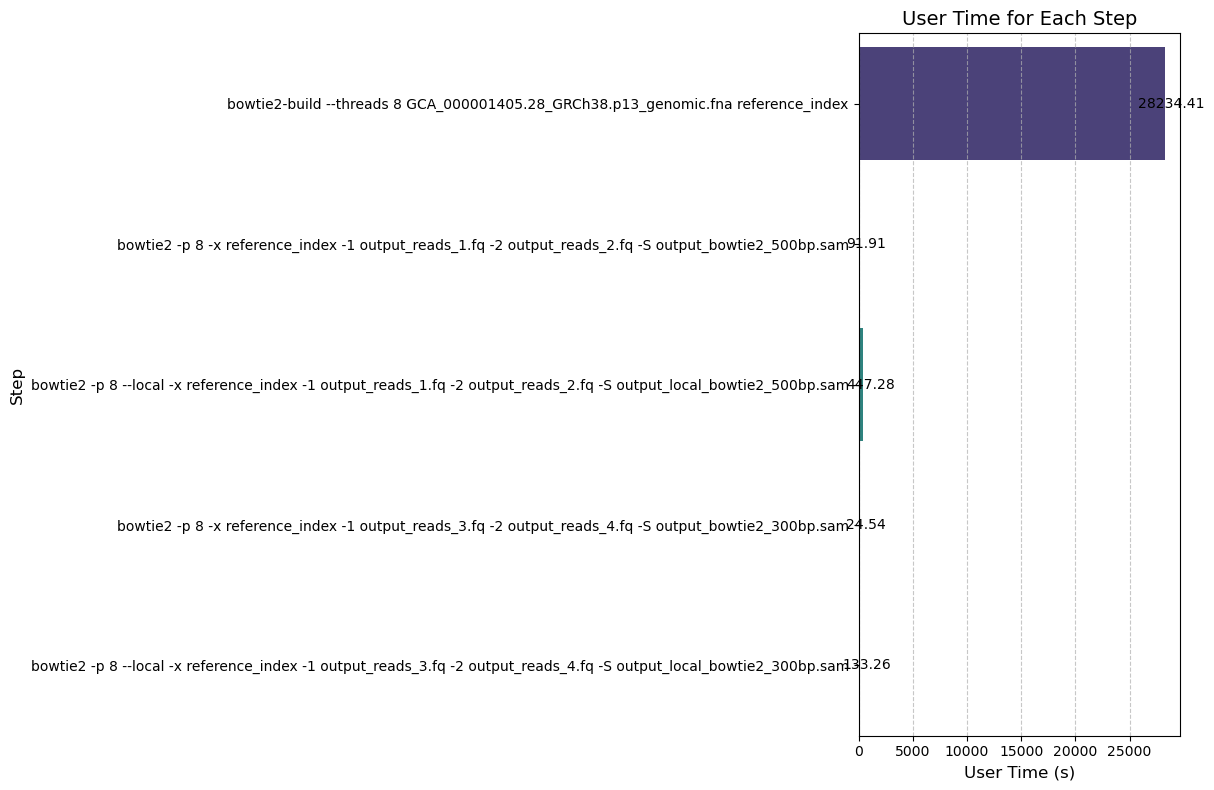

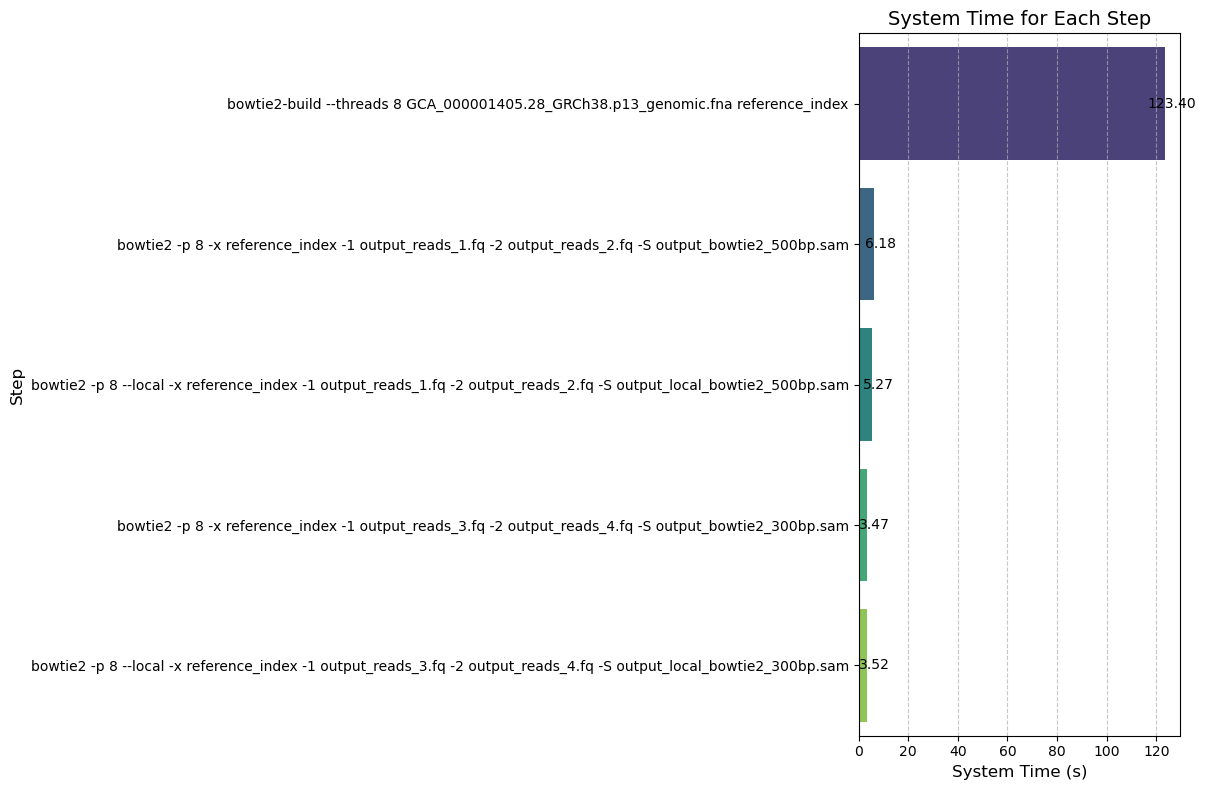

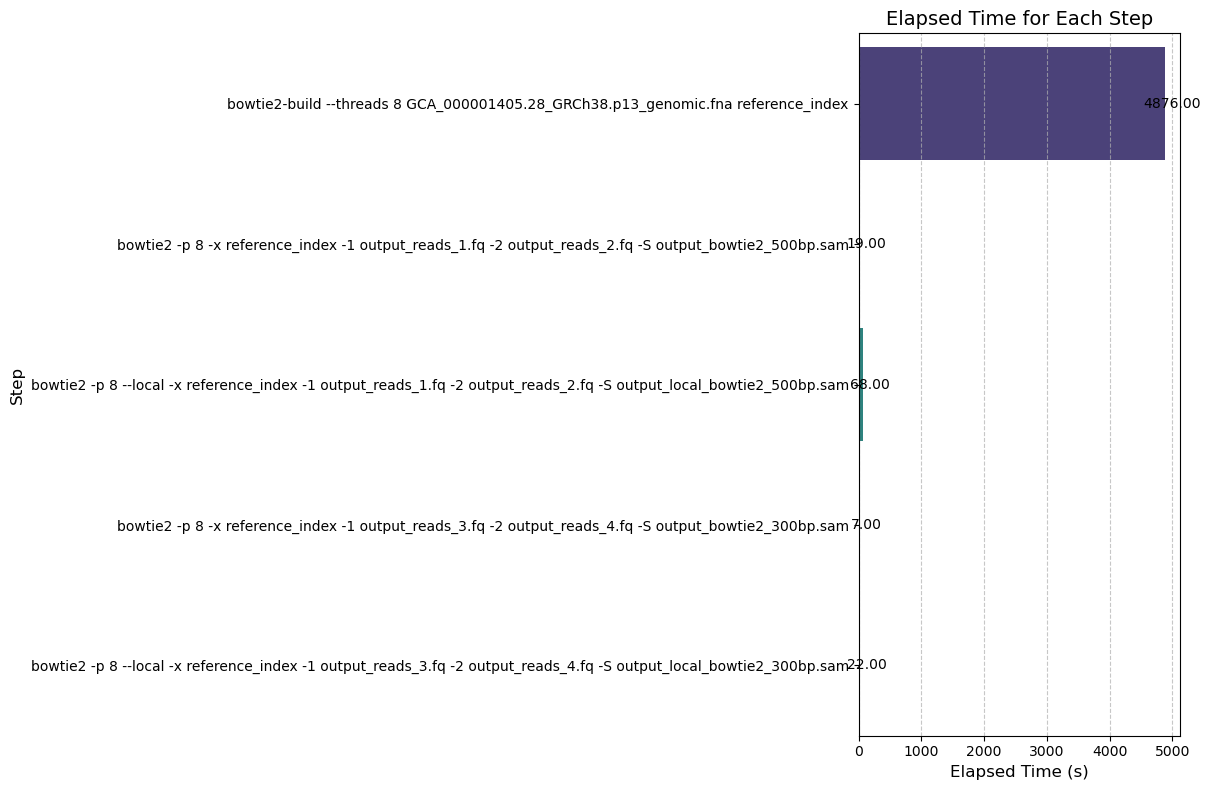

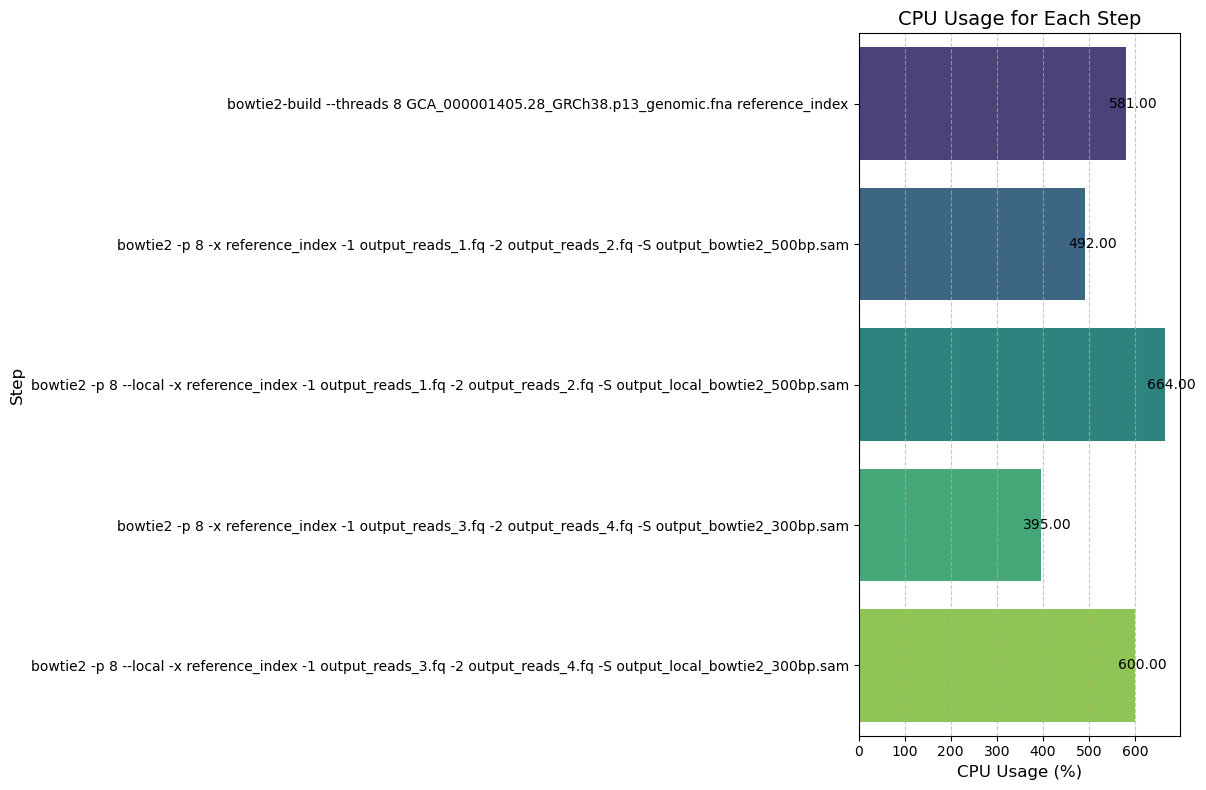

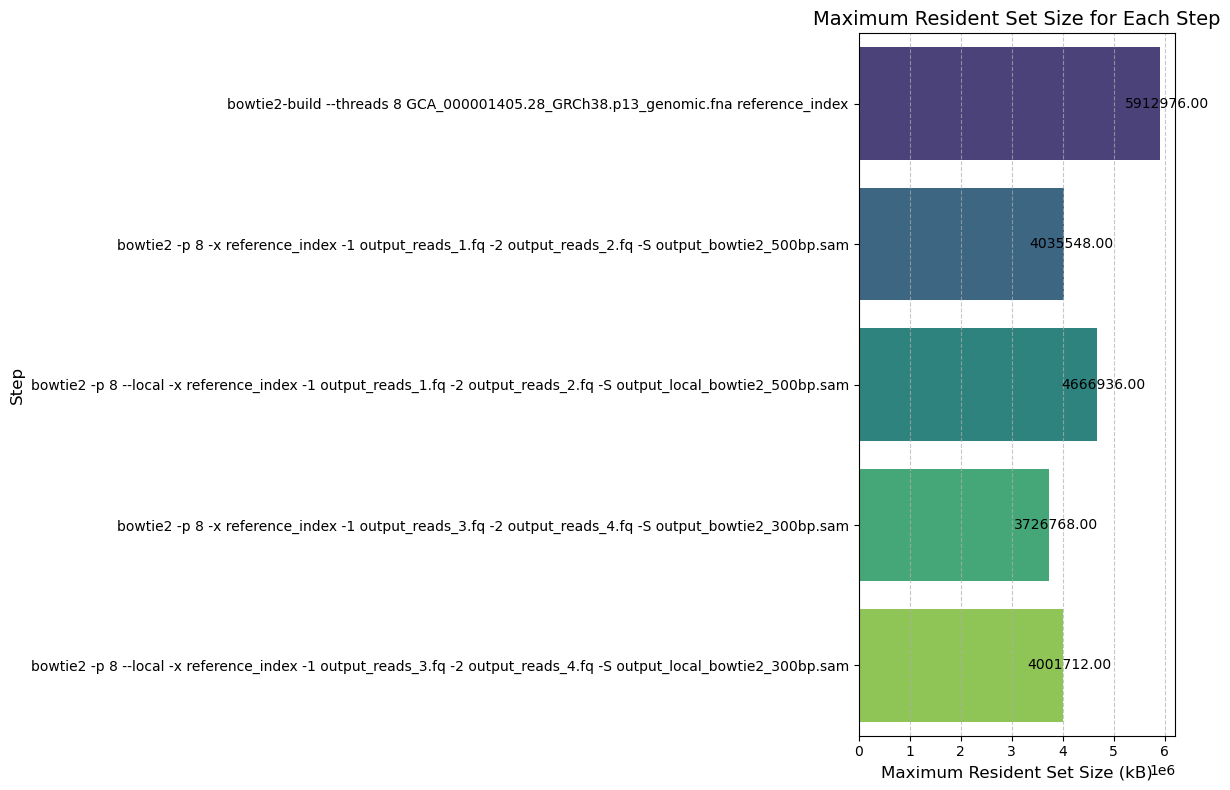

In [ ]:
# Plot all performance metrics from the Bowtie2 DataFrame
plot_all_log_metrics(df_bowtie2)

### 2. Parsing and Plotting Minimap2 Log Metrics

- **Load Minimap2 Log File**: We specify the path to the Minimap2 log file.
- **Parse Log File**: `parse_minimap2_log` extracts performance metrics from the log file and stores them in a DataFrame.
- **Display Metrics**: The resulting DataFrame is displayed.
- **Plot Metrics**: `plot_all_log_metrics` is used to visualize all key performance metrics from the Minimap2 log.

In [ ]:
# Path to the Minimap2 log file
minimap2_log_file = 'minimap2_script.log'

# Parse the Minimap2 log file to extract metrics into a DataFrame
df_minimap2 = parse_minimap2_log(minimap2_log_file)

# Display the DataFrame containing Minimap2 metrics
df_minimap2

,Step,User Time (s),System Time (s),Elapsed Time (s),CPU Usage (%),Maximum Resident Set Size (kB)
0,minimap2 -t 8 -d reference_index_minimap2.mmi ...,158.29,41.52,143.0,139.0,12606516
1,minimap2 -ax asm5 -t 8 reference_index_minimap...,21.15,9.87,20.0,152.0,8442892
2,minimap2 -ax sr -t 8 reference_index_minimap2....,12.71,10.45,20.0,111.0,8175460
3,minimap2 -ax sr -t 8 reference_index_minimap2....,39.19,10.54,24.0,200.0,8319452


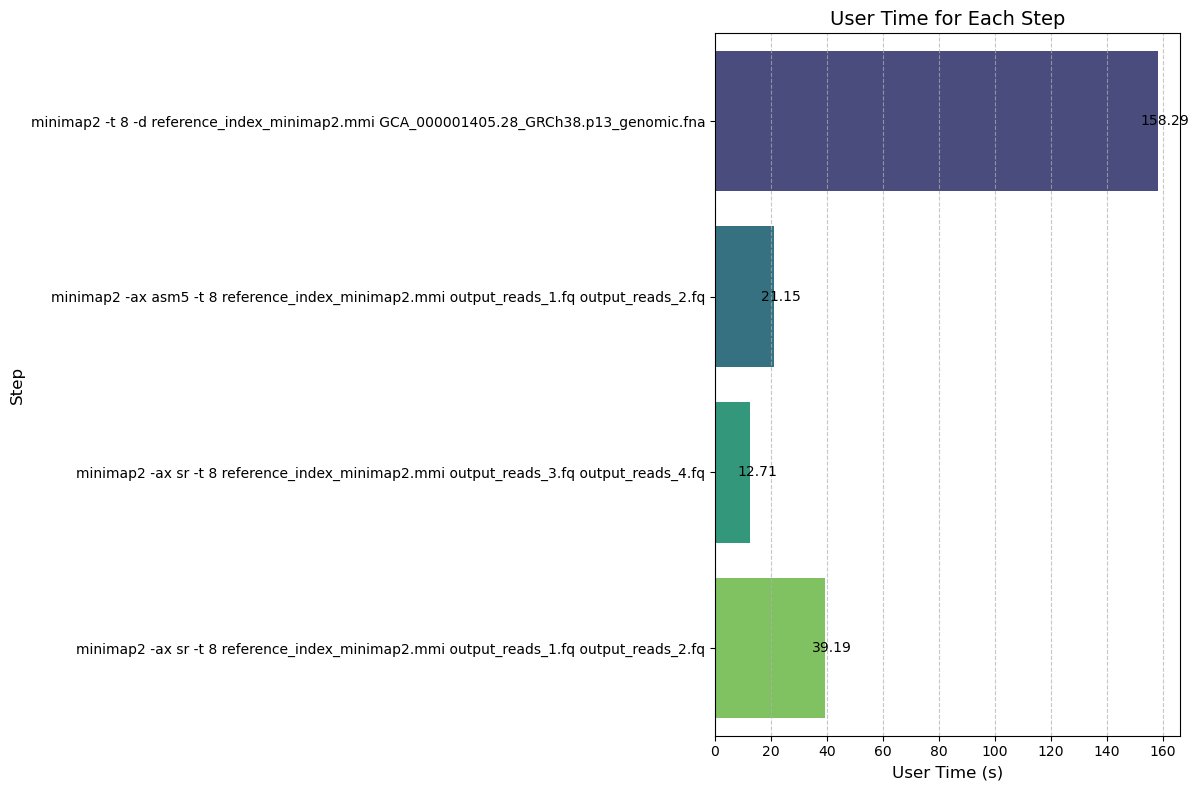

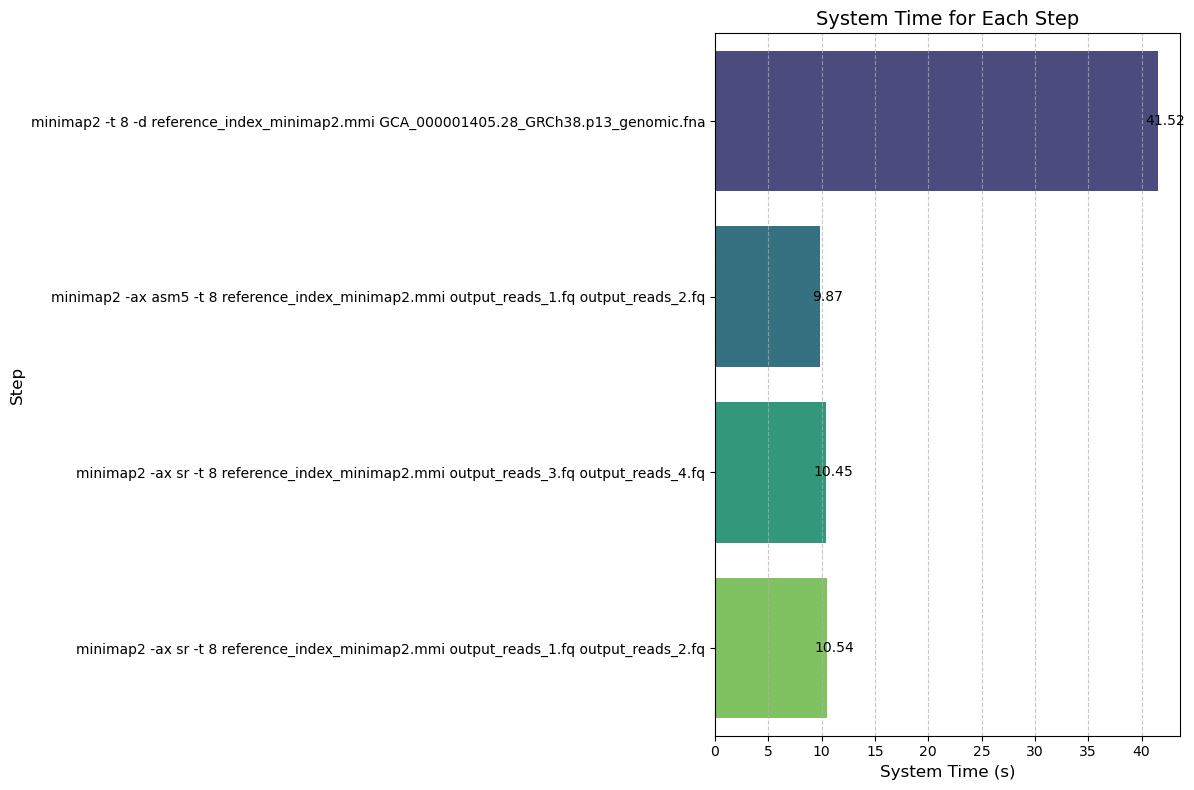

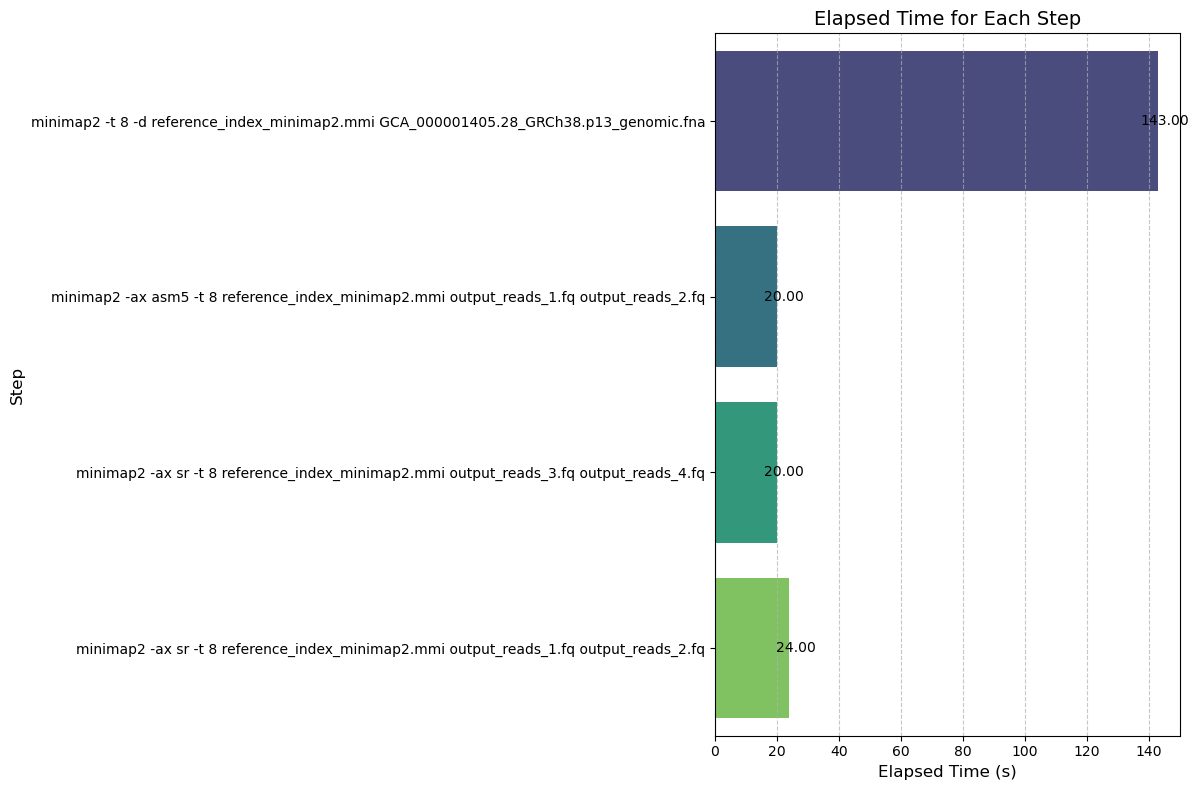

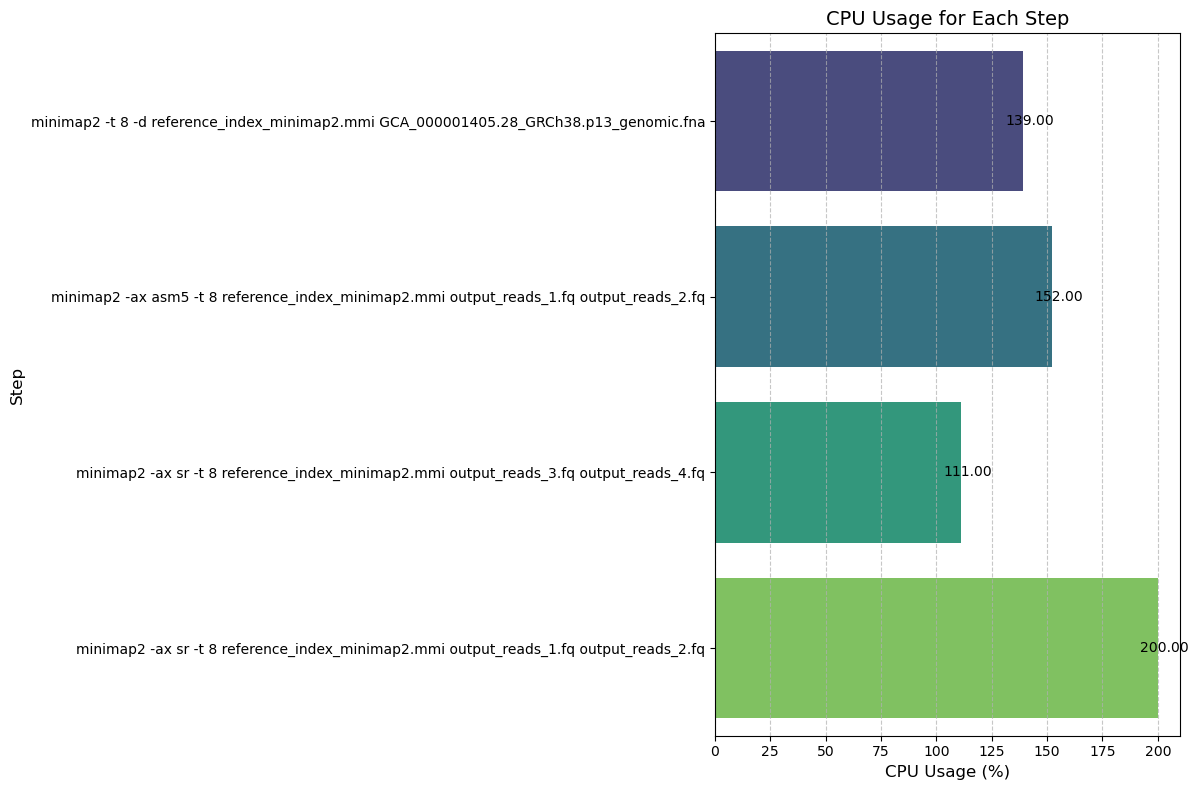

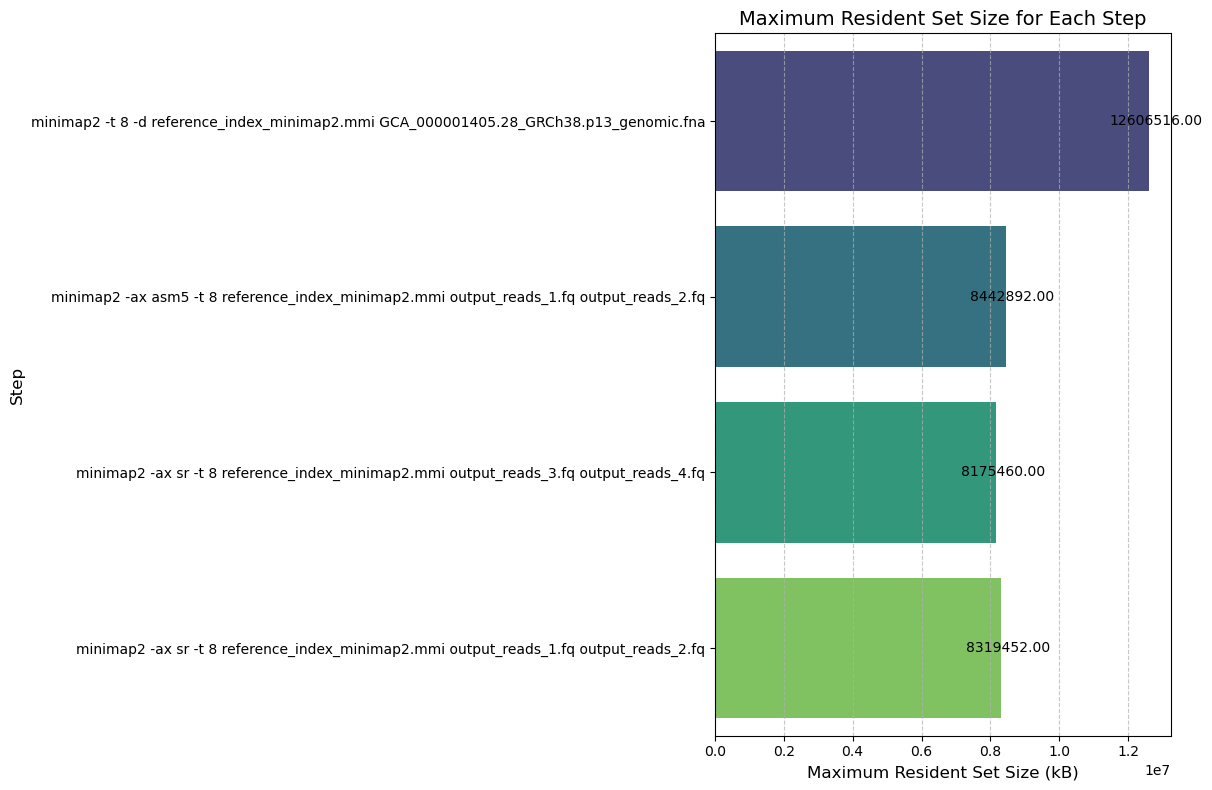

In [ ]:
# Plot all performance metrics from the Minimap2 DataFrame
plot_all_log_metrics(df_minimap2)

### 3. Parsing and Plotting GMAP Log Metrics

- **Load GMAP Log File**: We specify the path to the GMAP log file.
- **Parse Log File**: `parse_gmap_log` extracts performance metrics from the log file and stores them in a DataFrame.
- **Display Metrics**: The resulting DataFrame is displayed.
- **Plot Metrics**: `plot_all_log_metrics` is used to visualize all key performance metrics from the GMAP log.

In [ ]:
# Path to the GMAP log file
gmap_log_file = 'gmap_script.log'

# Parse the GMAP log file to extract metrics into a DataFrame
df_gmap = parse_gmap_log(gmap_log_file)

# Display the DataFrame containing GMAP metrics
df_gmap

,Step,User Time (s),System Time (s),Elapsed Time (s),CPU Usage (%),Maximum Resident Set Size (kB)
0,gmap_build -d GRCh38 -D genome_index_gmap GCA_...,7768.28,190.59,8230.0,96.0,31256544
1,gmap -d GRCh38 -D genome_index_gmap -f sampe -...,950.45,8.97,297.0,322.0,7314484
2,gmap -d GRCh38 -D genome_index_gmap -f sampe -...,1497.45,10.60,375.0,401.0,7908876


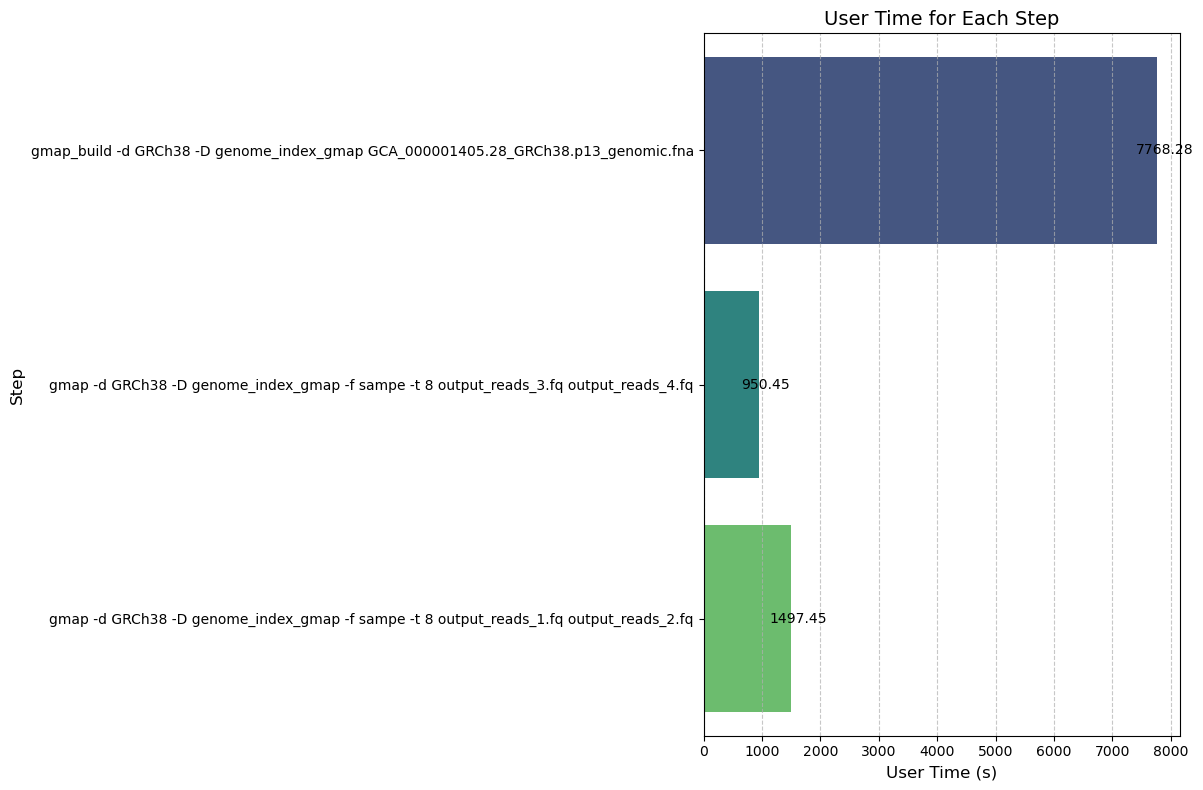

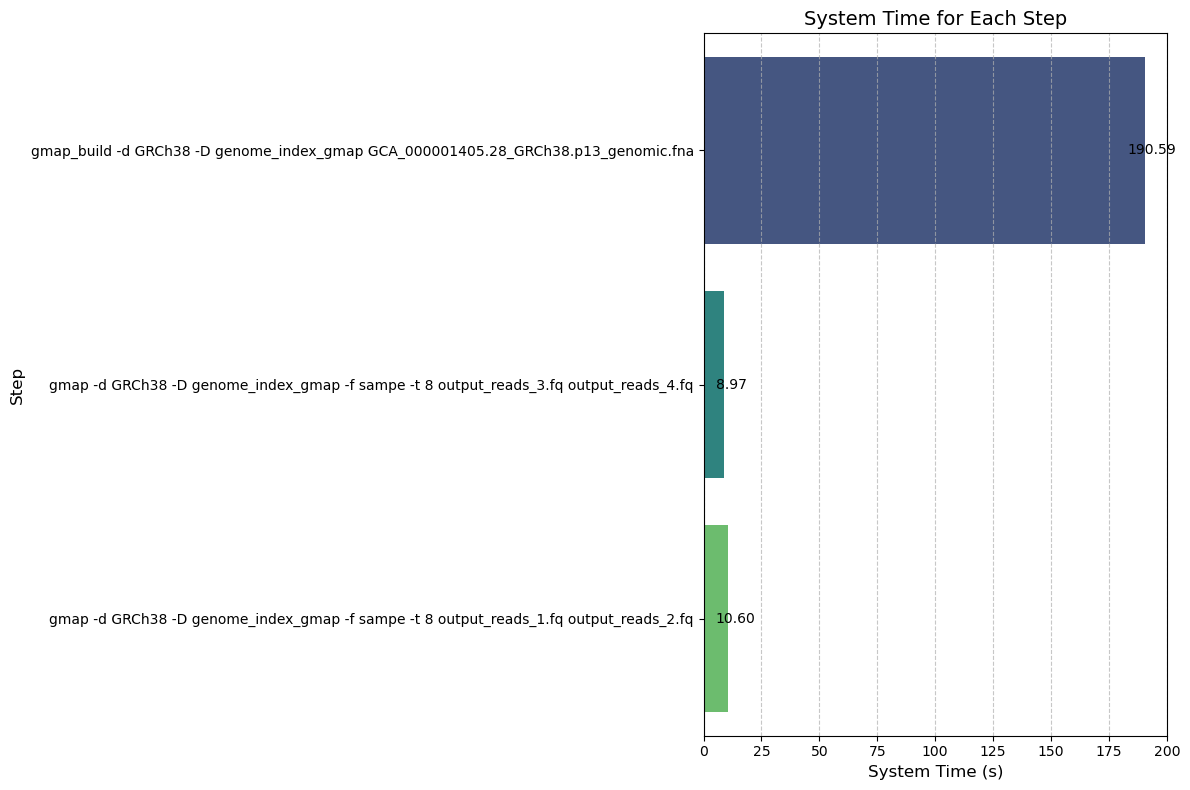

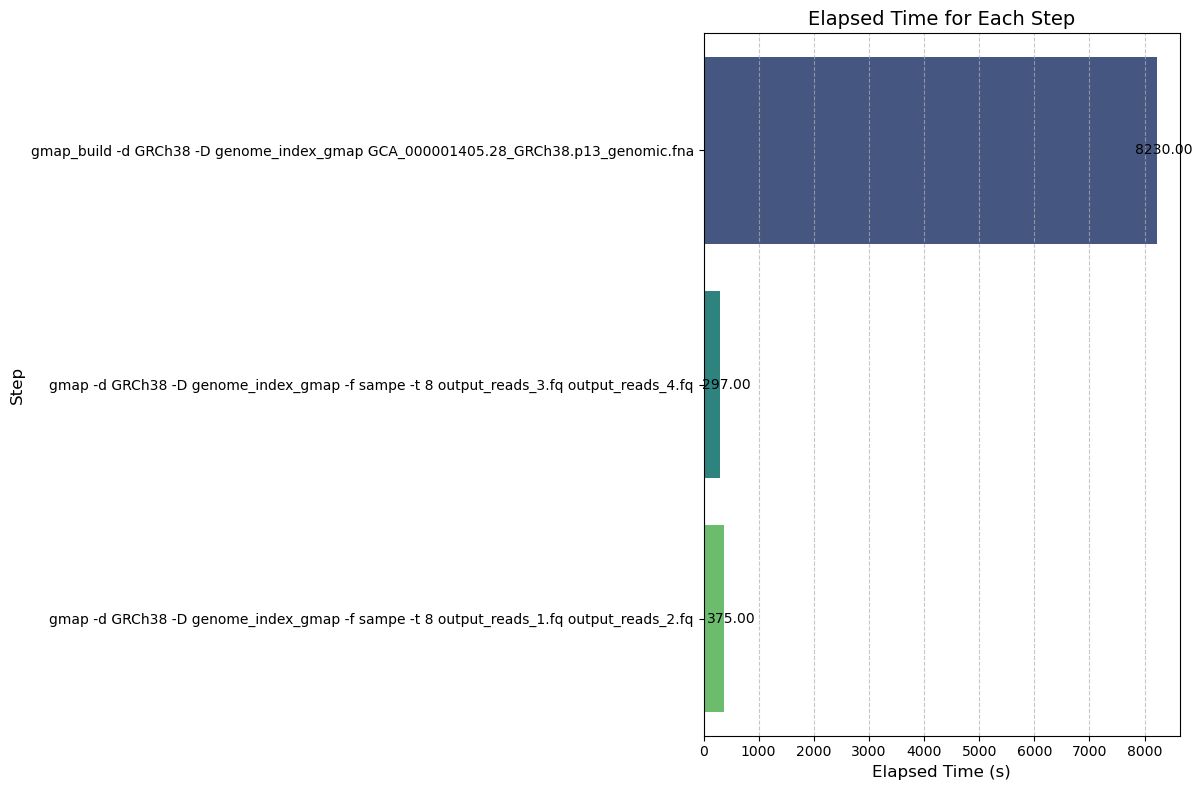

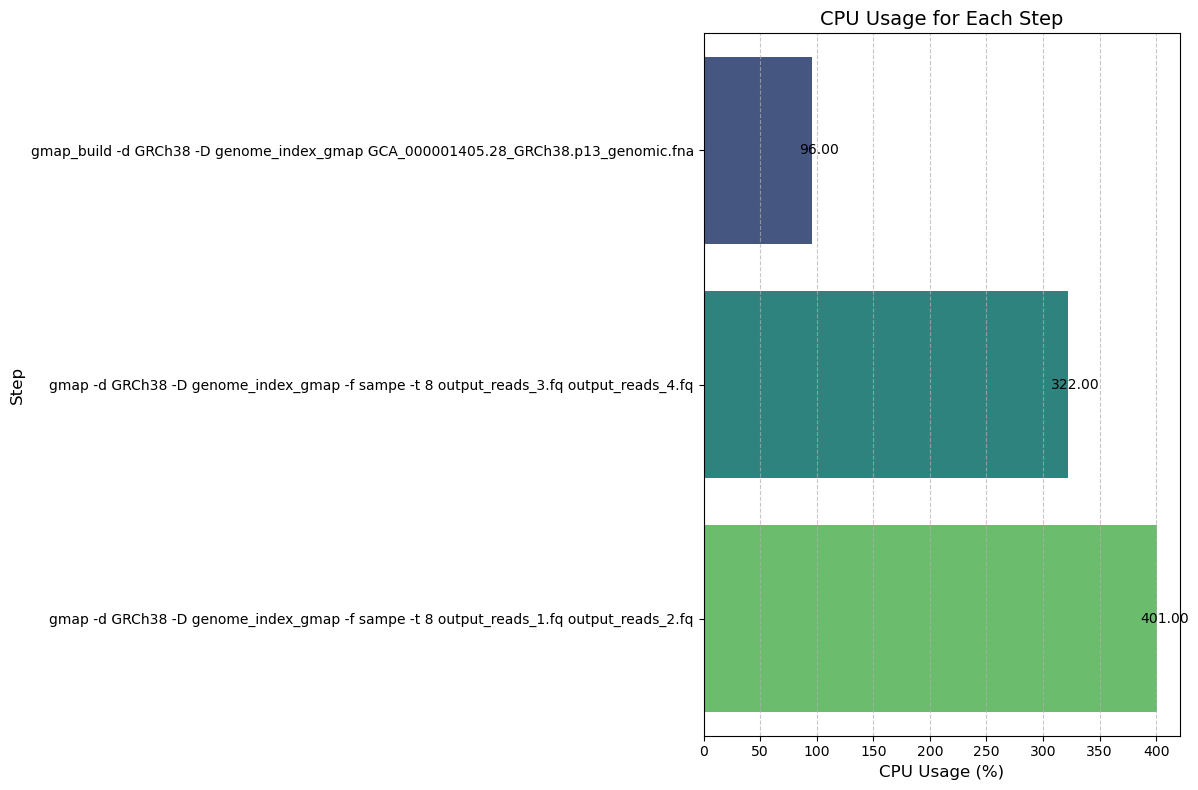

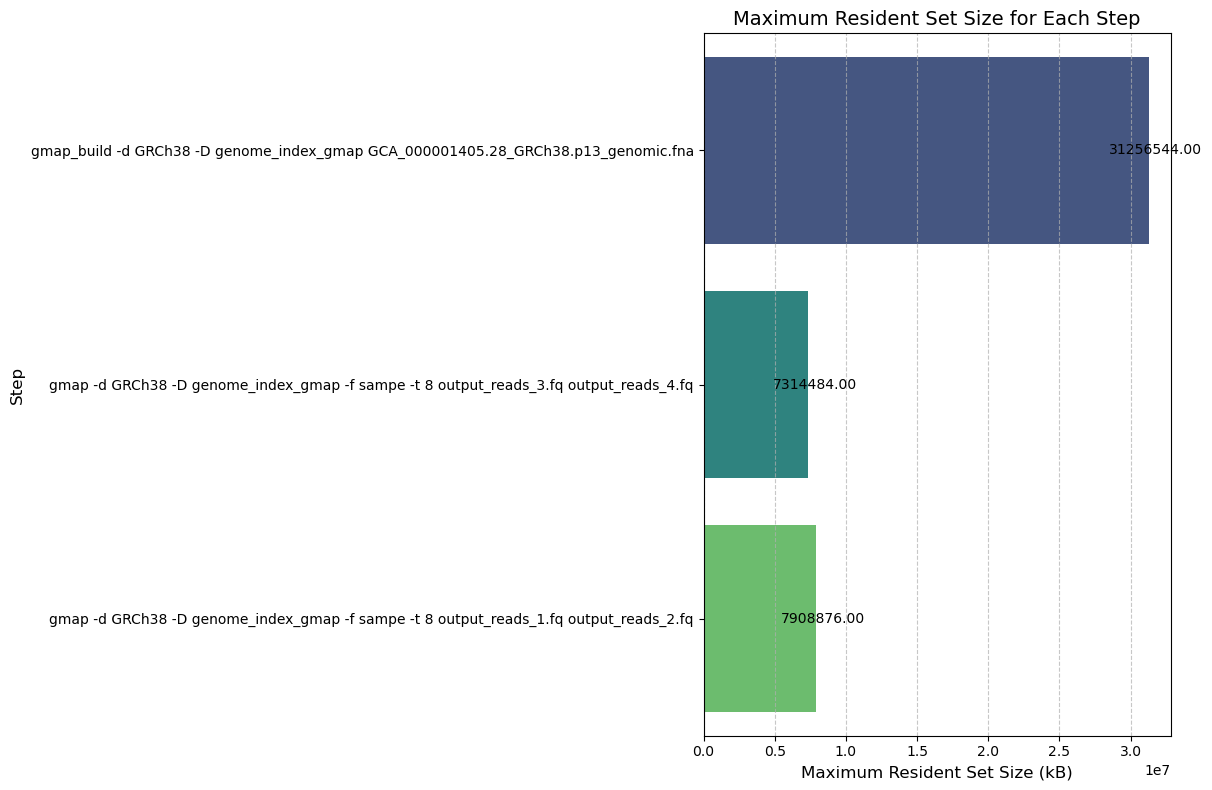

In [ ]:
# Plot all performance metrics from the GMAP DataFrame
plot_all_log_metrics(df_gmap)

### 4. Plotting the SAMtools Stats Metrics for the 300bp Sample

- **Load Stats Files**: Specify paths to the stats files for 300 bp reads from various aligners.
- **Create Data Dictionary**: `create_data_dict_300` generates a dictionary of metrics for each aligner.
- **Create DataFrame**: `create_dataframe` converts the data dictionary into a DataFrame for easier manipulation.
- **Display Metrics**: The resulting DataFrame is displayed.
- **Plot Metrics**: `plot_all_stats_metrics` visualizes all key metrics for the 300 bp reads.

In [ ]:
# Paths to the 300 bp stats files
data_300 = create_data_dict_300(
    'output_local_bowtie2_300bp_sorted_stats.txt',
    'output_bowtie2_300bp_sorted_stats.txt',
    'output_minimap2_300bp_sorted_stats.txt',
    'output_gmap_300bp_sorted_stats.txt'
)

# Create a DataFrame from the 300 bp data dictionary
df_300 = create_dataframe_300(data_300)

# Display the DataFrame containing 300 bp metrics
df_300

,Local Bowtie2,Bowtie2,Minimap2,GMAP
Metric,,,,
raw total sequences,20004.000000,20004.000000,20004.000000,28606.00000
reads mapped,20003.000000,19985.000000,20004.000000,28606.00000
reads unmapped,1.000000,19.000000,0.000000,0.00000
reads properly paired,12652.000000,9986.000000,20000.000000,0.00000
mismatches,130324.000000,77577.000000,64003.000000,149935.00000
error rate,0.022767,0.012939,0.010666,0.01754
average quality,20.000000,20.000000,20.000000,20.00000
alignment rate,0.999950,0.999050,1.000000,1.00000
accuracy,0.977233,0.987061,0.989334,0.98246


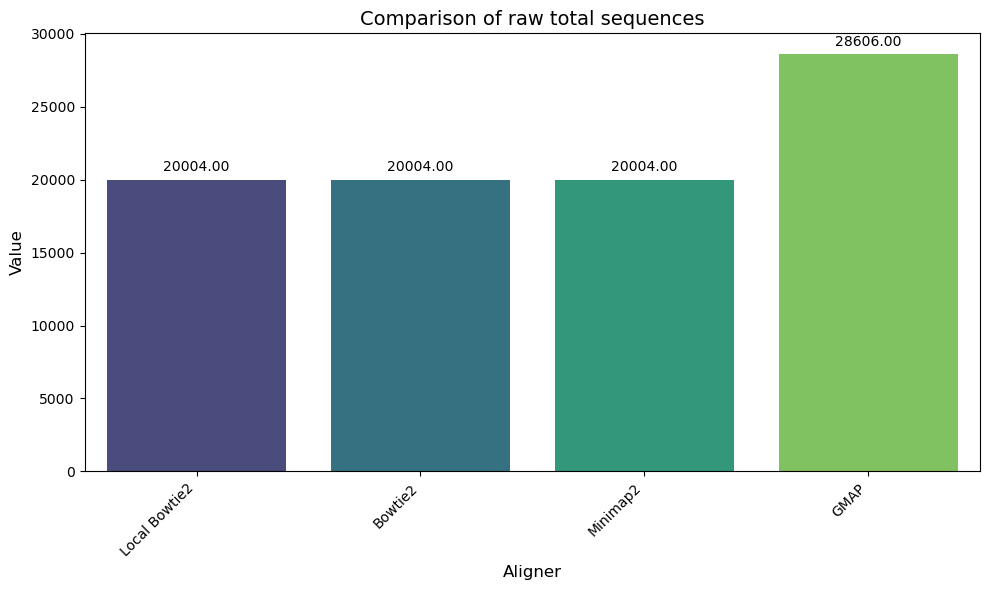

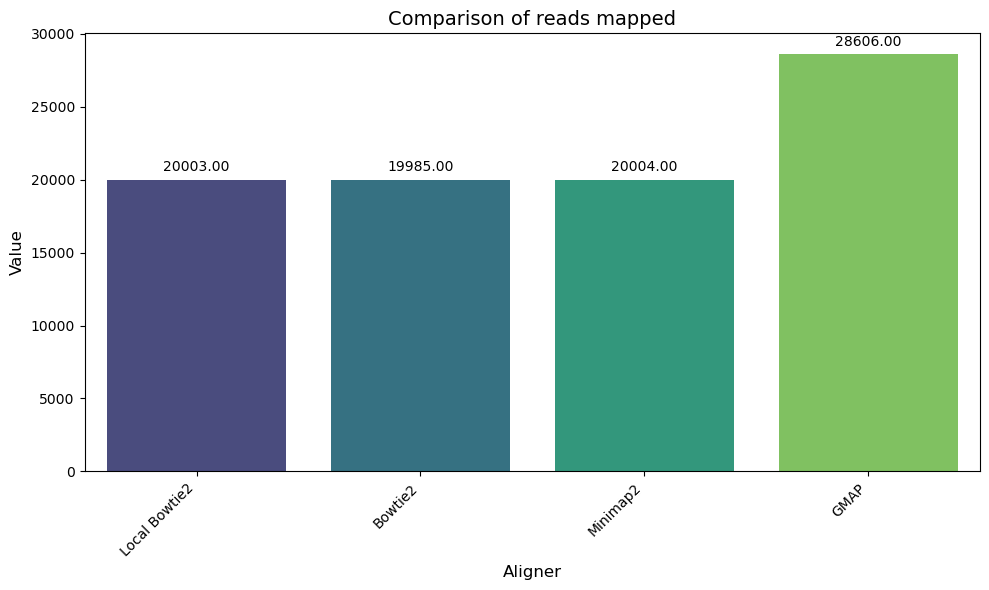

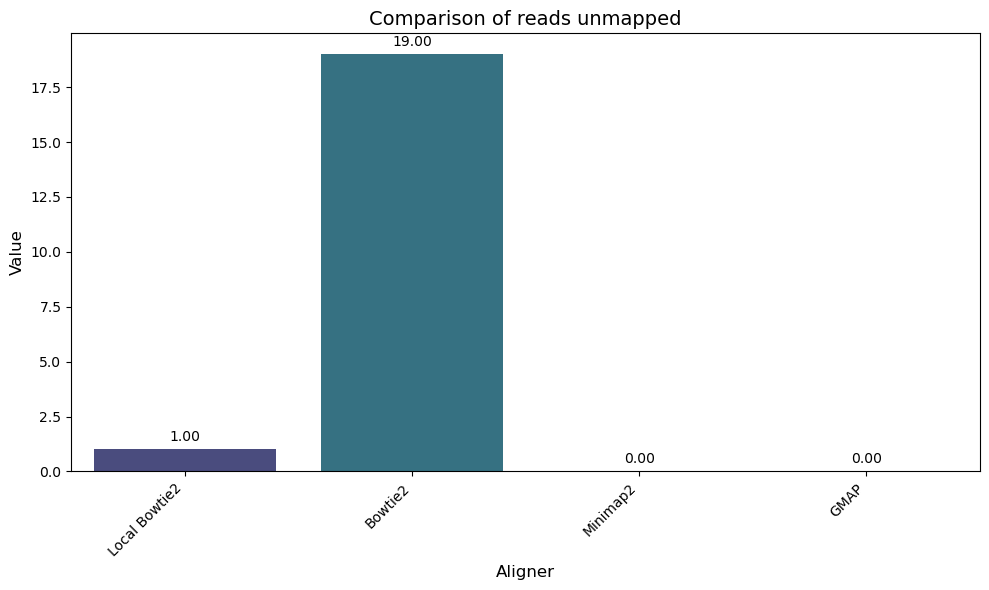

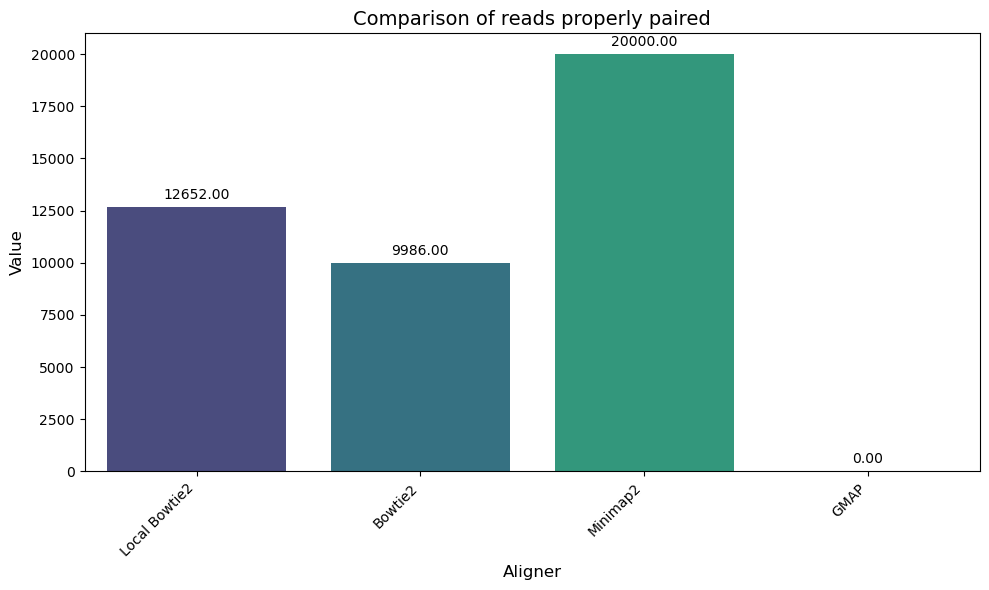

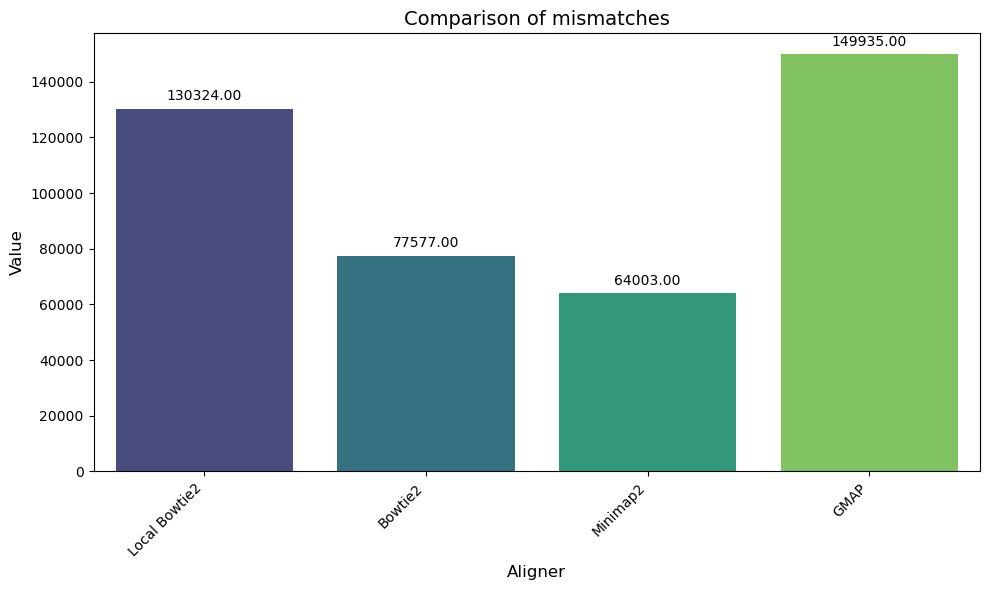

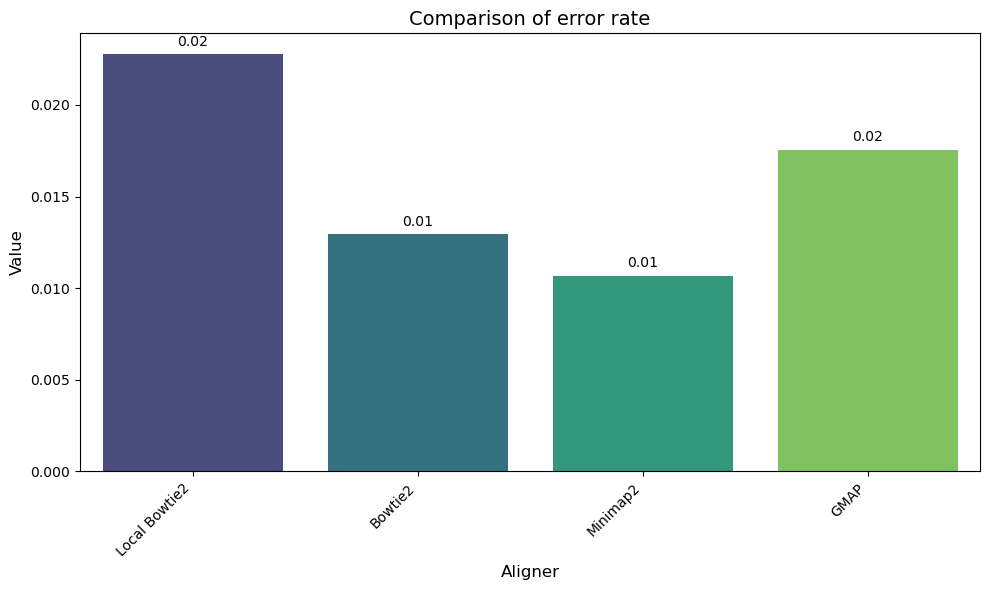

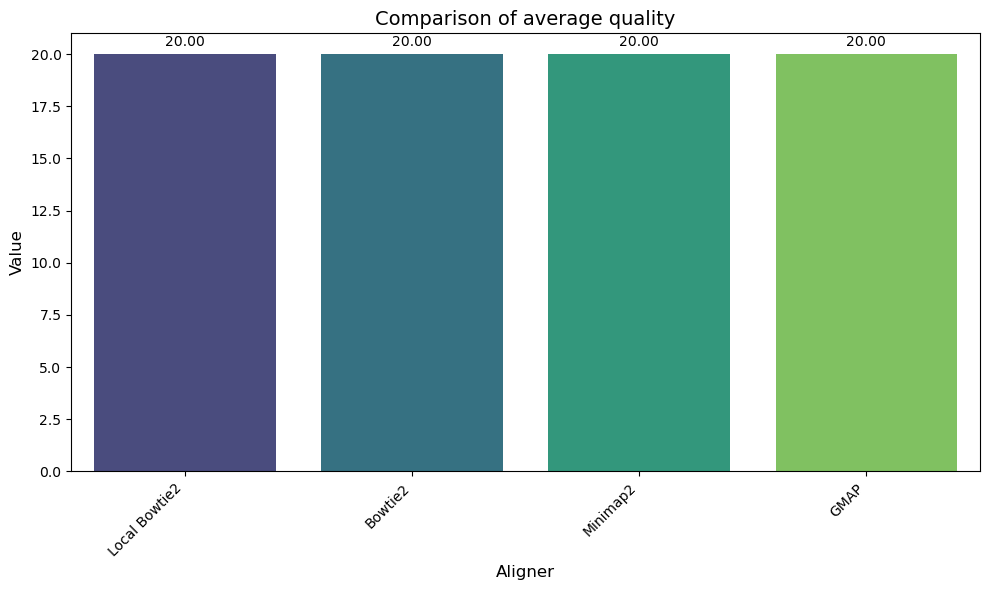

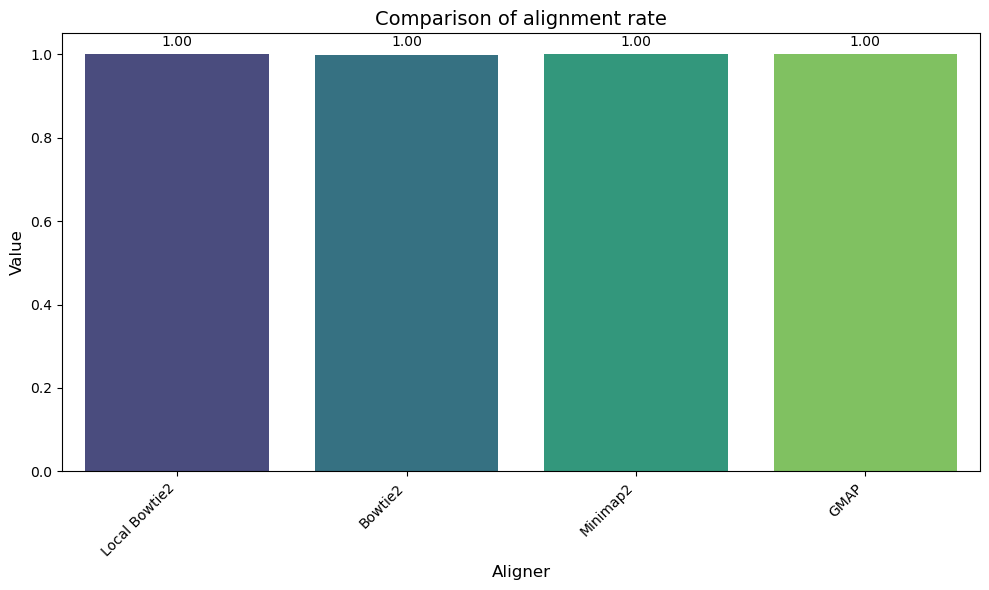

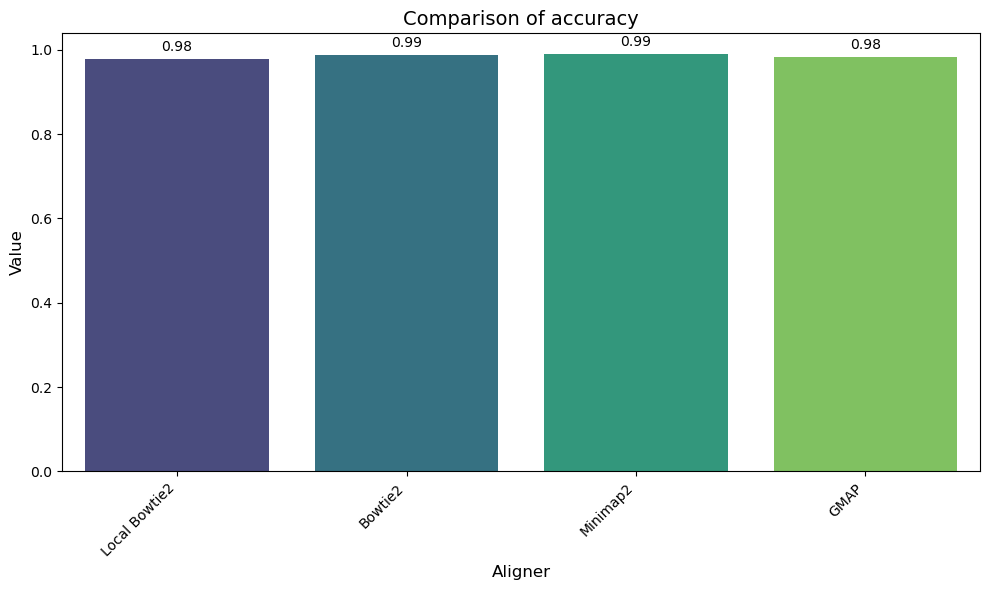

In [ ]:
# Plot all performance metrics from the 300 bp DataFrame
plot_all_stats_metrics(df_300)

### 4. Plotting the SAMtools Stats Metrics for the 500bp Sample

- **Load Stats Files**: Specify paths to the stats files for 500 bp reads from various aligners.
- **Create Data Dictionary**: `create_data_dict_500` generates a dictionary of metrics for each aligner.
- **Create DataFrame**: `create_dataframe` converts the data dictionary into a DataFrame for easier manipulation.
- **Display Metrics**: The resulting DataFrame is displayed.
- **Plot Metrics**: `plot_all_stats_metrics` visualizes all key metrics for the 500 bp reads.

In [ ]:
# Paths to the 500 bp stats files
data_500 = create_data_dict_500(
    'output_local_bowtie2_500bp_sorted_stats.txt',
    'output_bowtie2_500bp_sorted_stats.txt',
    'output_minimap2_500bp_sorted_stats.txt',
    'output_minimap2_asm5_500bp_sorted_stats.txt',
    'output_gmap_500bp_sorted_stats.txt'
)

# Create a DataFrame from the 500 bp data dictionary
df_500 = create_dataframe_500(data_500)

# Display the DataFrame containing 500 bp metrics
df_500

,Local Bowtie2,Bowtie2,Sensitive Minimap2,Assembly Minimap2,GMAP
Metric,,,,,
raw total sequences,20004.000000,20004.00000,20004.000000,20004.000000,28500.000000
reads mapped,20004.000000,19987.00000,20004.000000,19939.000000,28499.000000
reads unmapped,0.000000,17.00000,0.000000,65.000000,1.000000
reads properly paired,14260.000000,10160.00000,19908.000000,0.000000,0.000000
mismatches,270898.000000,115022.00000,107066.000000,97123.000000,264880.000000
error rate,0.030482,0.01151,0.010705,0.009834,0.018663
average quality,20.000000,20.00000,20.000000,20.000000,20.000000
alignment rate,1.000000,0.99915,1.000000,0.996751,0.999965
accuracy,0.969518,0.98849,0.989295,0.990166,0.981337


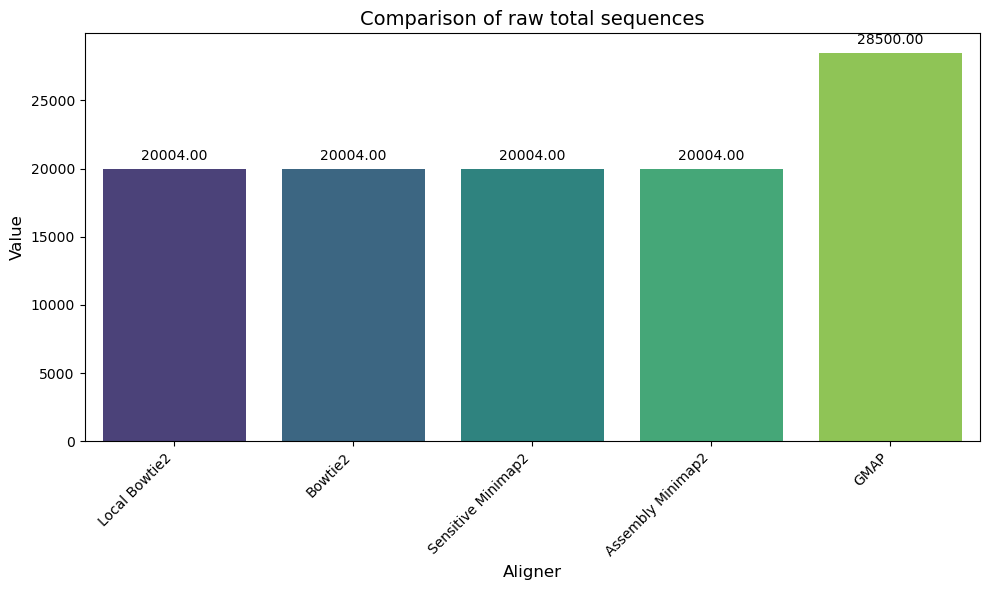

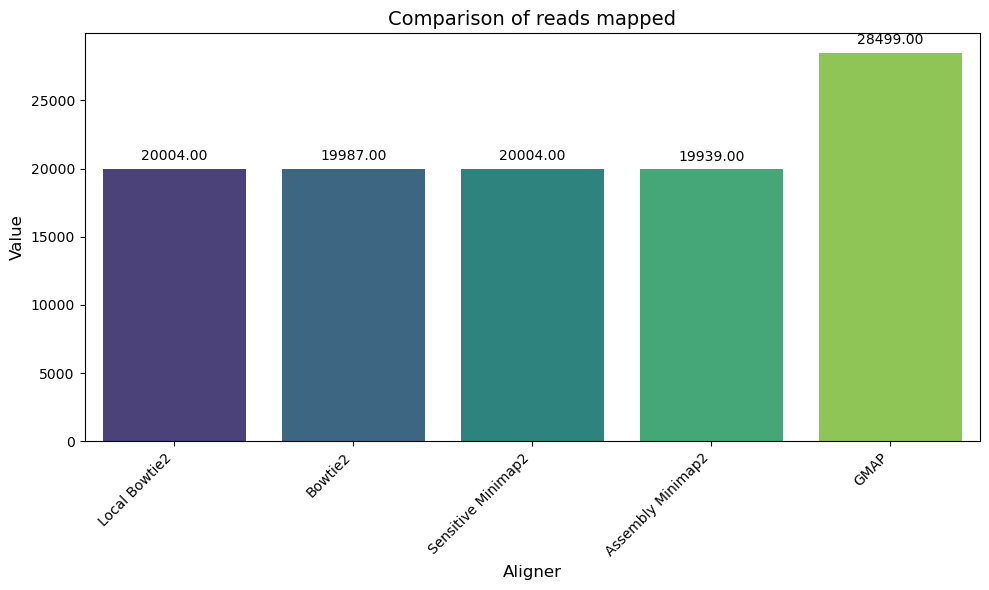

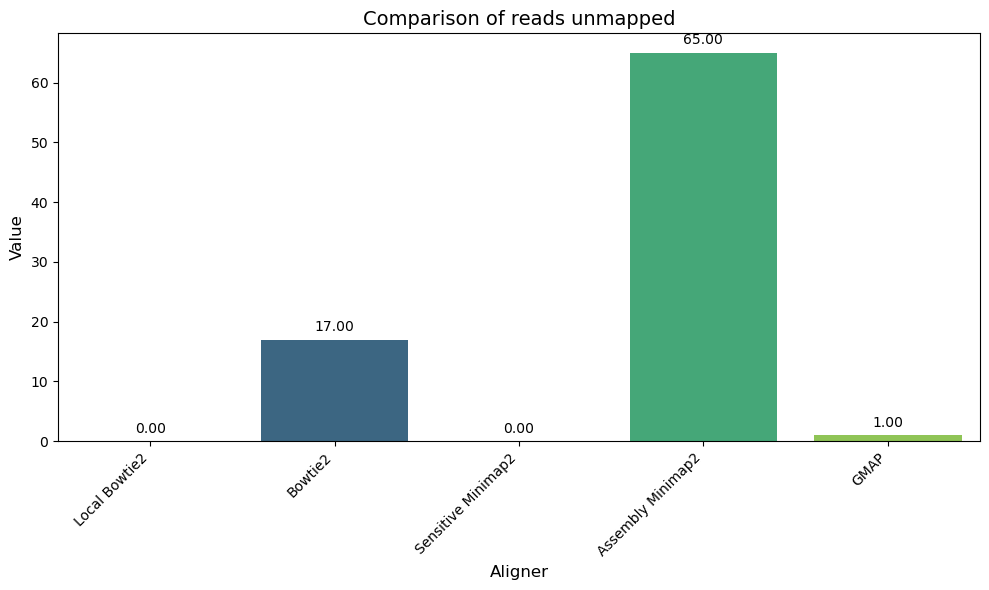

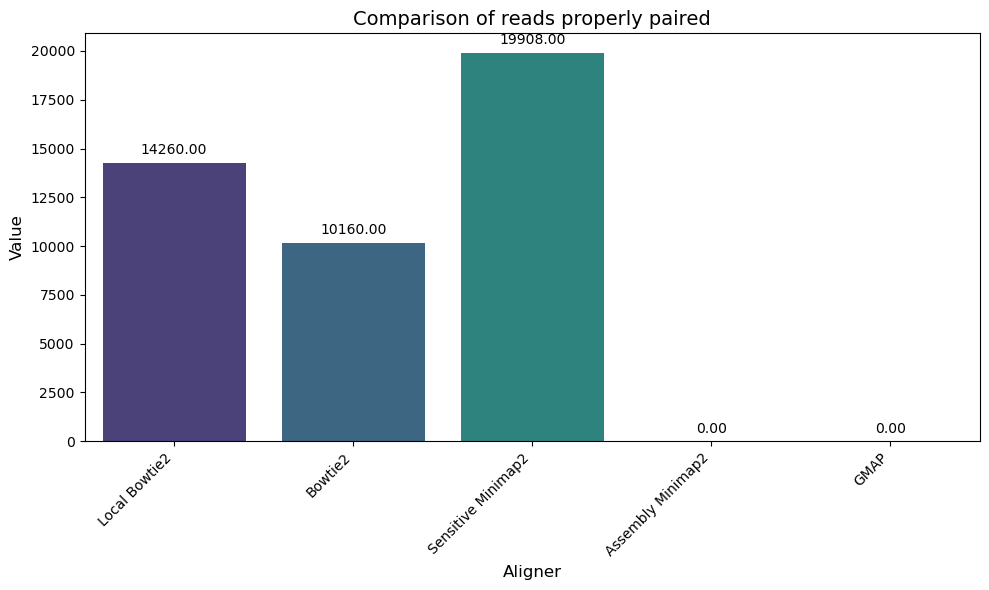

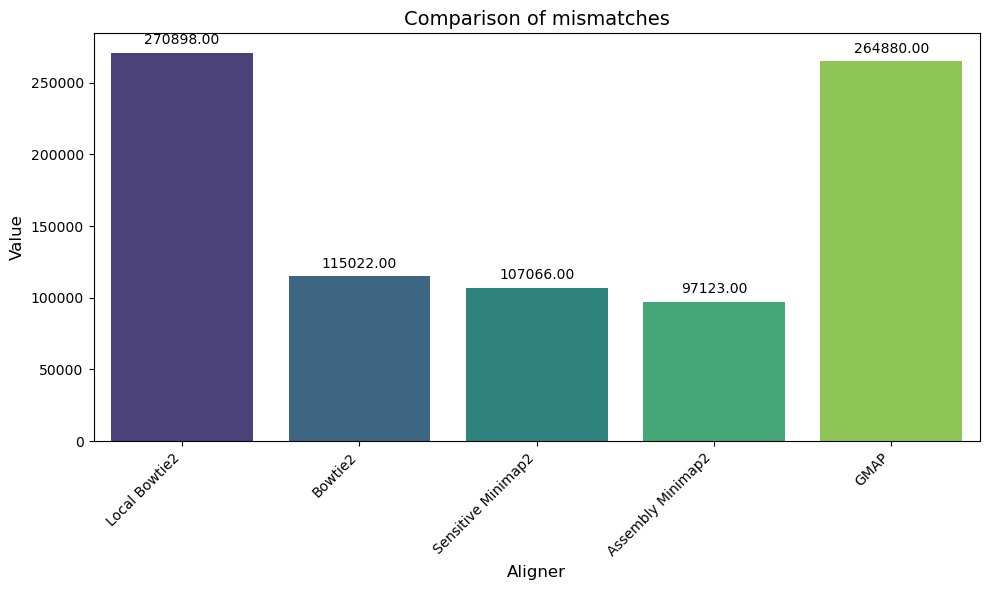

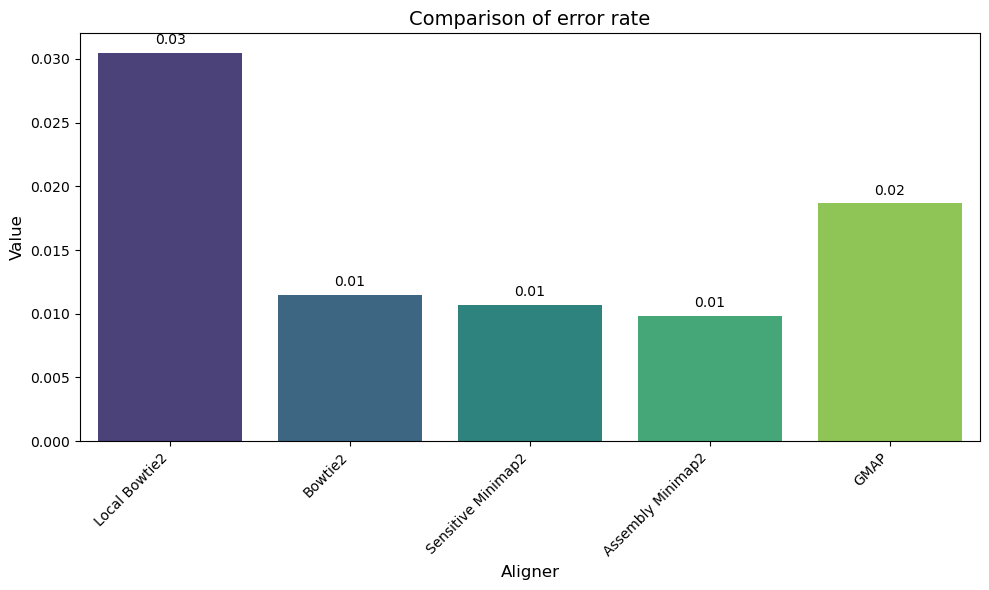

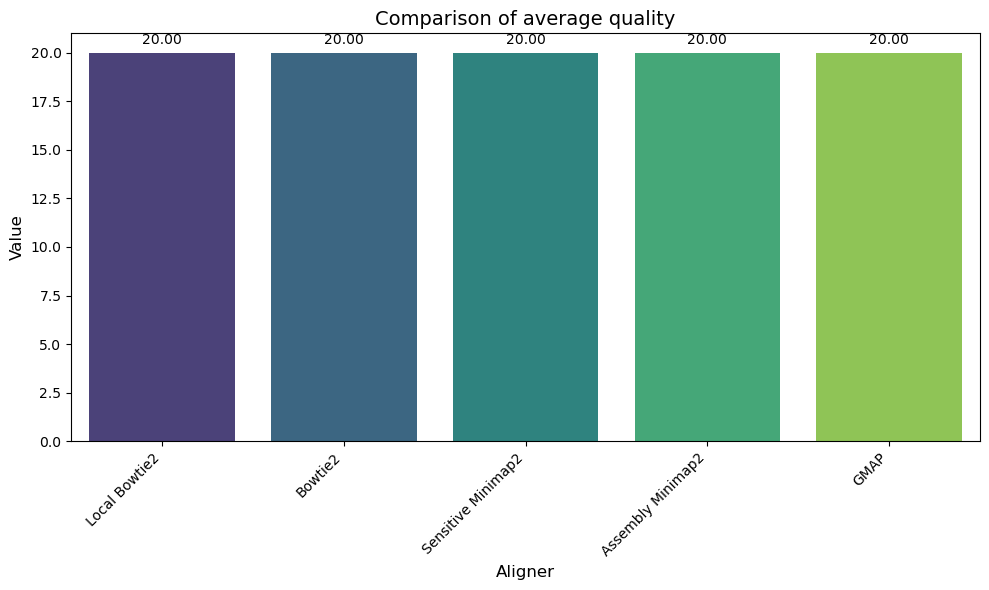

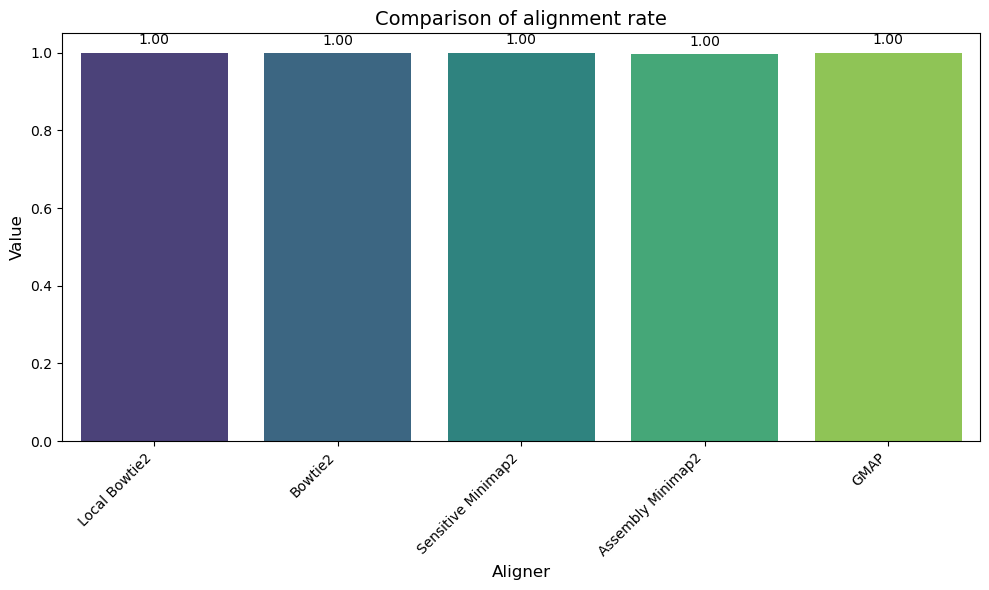

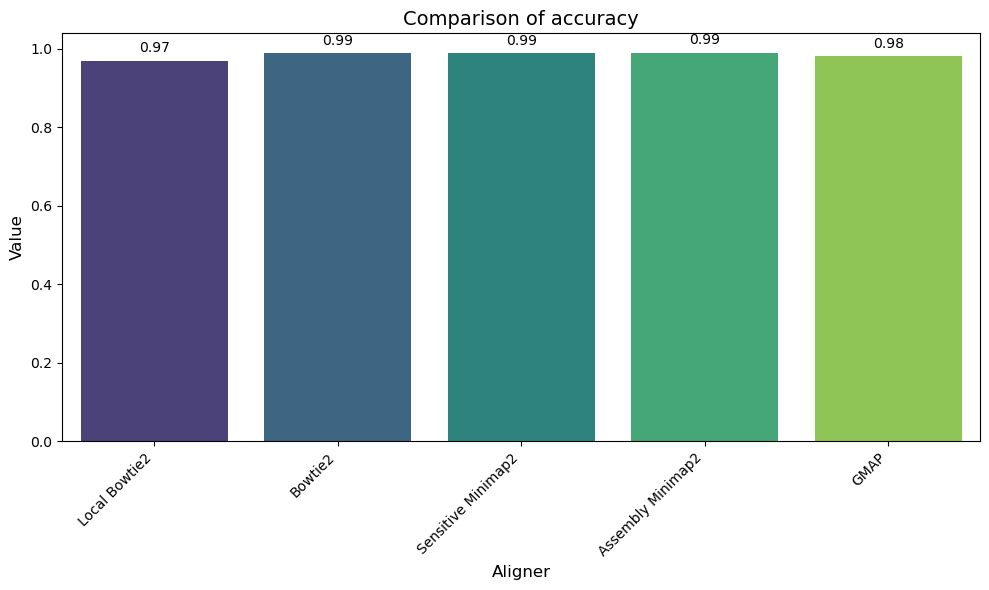

In [ ]:
# Plot all performance metrics from the 500 bp DataFrame
plot_all_stats_metrics(df_500)